In [416]:
%cd /Users/erin/Documents/Senior-Thesis/

/Users/erin/Documents/Senior-Thesis


In [417]:
pip install linearmodels

Note: you may need to restart the kernel to use updated packages.


In [418]:
import os
import io
import json
import pickle
import zipfile
from datetime import datetime, date
import re

import requests
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, LineString
import networkx as nx
import matplotlib.pyplot as plt
import contextily as ctx
import matplotlib.pyplot as plt

import numpy as np
from sklearn.cluster import DBSCAN
import folium
import ipywidgets as widgets
from IPython.display import display

import statsmodels.formula.api as smf
from pathlib import Path
from scipy import stats
from linearmodels.panel import PanelOLS
from shapely.ops import unary_union
from scipy.spatial.distance import cdist

import sys
try:
    import libpysal
    from libpysal.weights import DistanceBand
    from spreg import ML_Lag
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "libpysal", "spreg"])
    import libpysal
    from libpysal.weights import DistanceBand
    from spreg import ML_Lag

In [464]:
# Set shock year and analysis window
SHOCK_YEAR = 2019
YEAR_START = 2016
YEAR_END = 2023
BASELINE_YEAR = SHOCK_YEAR - 1  # year before shock (for heterogeneity)

# Treatment definition (used by main DiD, event study, lagged effects, dynamic, heterogeneity)
THRESHOLD_QUANTILE = 0.75  
CENTRALITY_COL = "eigen_or_katz_mean" 

# Event study / lagged effects
REL_MIN, REL_MAX = -3, 4   

Data Sources:
- Transit / GTFS: TransitLand ()
- Census Tract: United States Census Bureau ()

## Network Creation & Visualization

In [420]:
def load_gtfs(zip_path):
    """
    Load GTFS data from TransitLand zip file
    """
    with zipfile.ZipFile(zip_path, "r") as z:
        def read(name):
            return pd.read_csv(z.open(name))
        return (
            read("stops.txt"),
            read("routes.txt"),
            read("trips.txt"),
            read("stop_times.txt")
        )

def build_bus_graph(gtfs_zip_path):
    """
    Build a bus graph from a GTFS zip file
    """
    stops, routes, trips, stop_times = load_gtfs(gtfs_zip_path)

    # Clean / ensure correct types
    stops["stop_lat"] = stops["stop_lat"].astype(float)
    stops["stop_lon"] = stops["stop_lon"].astype(float)
    stops["stop_id"] = stops["stop_id"].astype(str)
    stop_times["stop_id"] = stop_times["stop_id"].astype(str)

    # Filter for bus routes (route_type = 3)
    bus_routes = routes[routes["route_type"] == 3]

    # Check for bus routes
    if len(bus_routes) == 0:
        raise ValueError("GTFS contains no bus routes (route_type = 3).")

    # Filter for bus trips and stop times
    bus_trips = trips[trips["route_id"].isin(bus_routes["route_id"])]
    st = stop_times[stop_times["trip_id"].isin(bus_trips["trip_id"])].copy()

    # Build graph
    G = nx.DiGraph()

    # Add all stops as nodes
    for _, r in stops.iterrows():
        G.add_node(
            r["stop_id"],
            name=r["stop_name"],
            lat=r["stop_lat"],
            lon=r["stop_lon"]
        )

    # Add edges (consecutive stops in each bus trip)
    for trip_id, group in st.groupby("trip_id"):
        group = group.sort_values("stop_sequence")

        prev = None
        for _, row in group.iterrows():
            sid = row["stop_id"]
            if prev is not None and prev != sid:
                G.add_edge(prev, sid, route=row["trip_id"])
            prev = sid

    return G

def graph_to_geodataframes(G):
    """
    Convert NetworkX graph to GeoDataFrames
    """
    # Add all stops as nodes
    nodes = []
    for nid, data in G.nodes(data=True):
        geom = Point(data["lon"], data["lat"])
        nodes.append({
            "stop_id": nid,
            "name": data.get("name"),
            "geometry": geom
        })

    gdf_nodes = gpd.GeoDataFrame(nodes, geometry="geometry", crs="EPSG:4326")

    # Add all routes as edges
    edges = []
    for u, v, data in G.edges(data=True):
        pu = Point(G.nodes[u]["lon"], G.nodes[u]["lat"])
        pv = Point(G.nodes[v]["lon"], G.nodes[v]["lat"])
        edges.append({
            "u": u,
            "v": v,
            "route": data.get("route"),
            "geometry": LineString([pu, pv])
        })

    gdf_edges = gpd.GeoDataFrame(edges, geometry="geometry", crs="EPSG:4326")

    return gdf_nodes, gdf_edges

In [421]:
def plot_rail_line(G, zoom_start=11):
    """
    Plot a rail line from a NetworkX graph
    """
    gdf_nodes, gdf_edges = graph_to_geodataframes(G)

    # Center map on average location
    center_lat = gdf_nodes.geometry.y.mean()
    center_lon = gdf_nodes.geometry.x.mean()

    # Create folium map
    m = folium.Map(location=[center_lat, center_lon], zoom_start=zoom_start)

    # Draw edges as polylines
    for _, row in gdf_edges.iterrows():
        coords = [(pt[1], pt[0]) for pt in row.geometry.coords] 
        folium.PolyLine(
            locations=coords,
            color="blue",
            weight=3,
            opacity=0.7,
            tooltip=f"{row['u']} → {row['v']} (routes: {row['routes']})"
        ).add_to(m)

    # Draw nodes as circles
    for _, row in gdf_nodes.iterrows():
        folium.CircleMarker(
            location=[row.geometry.y, row.geometry.x],
            radius=4,
            color="red",
            fill=True,
            fill_color="red",
            popup=(
                f"<b>Stop ID:</b> {row['stop_id']}<br>"
                f"<b>Name:</b> {row['name']}<br>"
                f"<b>Parent Station:</b> {row['parent']}"
            )
        ).add_to(m)

    return m

In [422]:
def build_dict(folder_path):
    """Build a dict of year -> path for GTFS zip files in folder."""
    gtfs_files = {}
    for fname in os.listdir(folder_path):
        if len(fname) >= 4 and fname[:4].isdigit() and fname.endswith(".zip"):
            year = int(fname[:4])
            gtfs_files[year] = os.path.join(folder_path, fname)
    return gtfs_files

In [423]:
def _graphs_dir_for(folder_path, graphs_base="data/graphs"):
    """Derive graphs save path from GTFS folder. Uses folder basename as location (e.g. data/raw/Indy -> Indy)."""
    abs_folder = os.path.abspath(folder_path.rstrip(os.sep))
    location = os.path.basename(abs_folder)
    project_root = os.path.dirname(os.path.dirname(os.path.dirname(abs_folder)))
    return os.path.join(project_root, graphs_base, location)

def save_graphs(graphs, graphs_dir):
    """Save graphs to graphs_dir as year.gpickle."""
    os.makedirs(graphs_dir, exist_ok=True)
    for year, G in graphs.items():
        path = os.path.join(graphs_dir, f"{year}.gpickle")
        with open(path, "wb") as f:
            pickle.dump(G, f, protocol=pickle.HIGHEST_PROTOCOL)

def load_graphs(graphs_dir):
    """Load graphs from graphs_dir. Returns (graphs, nodes_gdf, edges_gdf) or None if missing."""
    if not os.path.isdir(graphs_dir):
        return None
    graphs = {}
    for fname in os.listdir(graphs_dir):
        if fname.endswith(".gpickle"):
            year = int(fname.replace(".gpickle", ""))
            path = os.path.join(graphs_dir, fname)
            with open(path, "rb") as f:
                graphs[year] = pickle.load(f)
    if not graphs:
        return None
    nodes_gdf = {}
    edges_gdf = {}
    for year, G in graphs.items():
        g_nodes, g_edges = graph_to_geodataframes(G)
        nodes_gdf[year] = g_nodes
        edges_gdf[year] = g_edges
    return graphs, nodes_gdf, edges_gdf

def build_graphs(folder_path, graphs_base="data/graphs", force_rebuild=False):
    """
    Build or load bus network graphs from GTFS zip files.

    - folder_path: folder with TransitLand GTFS zips (e.g. data/raw/Indy)
    - graphs_base: base dir for cached graphs (default data/graphs)
    - force_rebuild: if True, rebuild from zips even when cache exists

    Returns: (graphs, nodes_gdf, edges_gdf)
    Saves to data/graphs/{location}/ for reuse.
    """
    graphs_dir = _graphs_dir_for(folder_path, graphs_base)

    if not force_rebuild:
        loaded = load_graphs(graphs_dir)
        if loaded is not None:
            graphs, nodes_gdf, edges_gdf = loaded
            print(f"Loaded {len(graphs)} cached graphs from {graphs_dir}")
            return graphs, nodes_gdf, edges_gdf

    graphs = {}
    nodes_gdf = {}
    edges_gdf = {}

    gtfs_paths = build_dict(folder_path)
    if not gtfs_paths:
        raise FileNotFoundError(f"No GTFS zip files found in {folder_path}")

    for year in sorted(gtfs_paths.keys()):
        path = gtfs_paths[year]
        print(f"\nBuilding graph for {year} ...")
        try:
            G = build_bus_graph(path)
            graphs[year] = G
            g_nodes, g_edges = graph_to_geodataframes(G)
            nodes_gdf[year] = g_nodes
            edges_gdf[year] = g_edges
            print(f"Successfully built graph for {year} with {len(G.nodes())} nodes and {len(G.edges())} edges.")
        except Exception as e:
            print(f"Error building graph for {year}: {e}")

    save_graphs(graphs, graphs_dir)
    print(f"\nSaved graphs to {graphs_dir}")
    return graphs, nodes_gdf, edges_gdf


def graph_nodes_dict(G):
    """Return lightweight dict of stop_id -> metadata for rendering."""
    return {
        nid: {"name": data.get("name"), "lat": float(data.get("lat")), "lon": float(data.get("lon"))}
        for nid, data in G.nodes(data=True)
    }


def graph_edges_list(G):
    """Return simple list of (u, v) edges for rendering."""
    return [(u, v) for u, v in G.edges()]


# Global caches for render_map_year (set by get_graphs_for_rendering)
node_cache = {}
edge_cache = {}


def get_graphs_for_rendering(gtfs_folder=None, graphs_dir=None, force_rebuild=False):
    """
    Load graphs and prepare for rendering. Use one of:
    - graphs_dir: load from cache only (e.g. data/graphs/Indy) - no GTFS needed
    - gtfs_folder: build or load from GTFS folder

    Returns (graphs, nodes_gdf, edges_gdf) and prepares caches for render_map_year.
    """
    global node_cache, edge_cache

    if graphs_dir is not None:
        loaded = load_graphs(graphs_dir)
        if loaded is None:
            raise FileNotFoundError(f"No cached graphs found at {graphs_dir}")
        graphs, nodes_gdf, edges_gdf = loaded
        print(f"Loaded {len(graphs)} graphs from cache for rendering")
    elif gtfs_folder is not None:
        graphs, nodes_gdf, edges_gdf = build_graphs(gtfs_folder, force_rebuild=force_rebuild)
    else:
        raise ValueError("Provide either gtfs_folder or graphs_dir")

    node_cache.clear()
    edge_cache.clear()
    for year, G in graphs.items():
        node_cache[year] = graph_nodes_dict(G)
        edge_cache[year] = graph_edges_list(G)

    return graphs, nodes_gdf, edges_gdf


In [424]:
graphs_dir = "data/graphs/Indy"
gtfs_folder = "data/raw/Indy"

# Resolve paths (works from project root or src/)
if not os.path.exists(graphs_dir):
    graphs_dir = os.path.join("..", graphs_dir)
if not os.path.exists(gtfs_folder):
    gtfs_folder = os.path.join("..", gtfs_folder)
# Fallback for legacy path
if not os.path.exists(gtfs_folder):
    gtfs_folder = "data/Indy/Indy Transportation Data"

# Try cache first, fall back to GTFS if cache doesn't exist
if os.path.isdir(graphs_dir) and load_graphs(graphs_dir) is not None:
    graphs, nodes_gdf, edges_gdf = get_graphs_for_rendering(graphs_dir=graphs_dir)
else:
    graphs, nodes_gdf, edges_gdf = get_graphs_for_rendering(gtfs_folder=gtfs_folder)

Loaded 10 graphs from cache for rendering


In [425]:
def compare_station_names(graphs, year1, year2):
    """
    Compare station names between two years.
    Simple check function to ensure new GTFS data is consistent
    """
    G1 = graphs[year1]
    G2 = graphs[year2]

    names1 = {data["name"] for _, data in G1.nodes(data=True)}
    names2 = {data["name"] for _, data in G2.nodes(data=True)}

    added = names2 - names1
    removed = names1 - names2

    print("ADDED:", added)
    print("REMOVED:", removed)
compare_station_names(graphs, 2022, 2023)

ADDED: {'Lynhurst Dr & Great Woods Dr', '29th St & Annette St', 'Charnock St & E. 33rd St - IndyGo East C', 'Keystone Crossing & Woodfield Crossing B', '38th St & Shopping Center Dr-Northeastwo', '7200 E Clearvista Way - Community Hosp N', 'Beachway Dr & Lawndale Ave', 'Vermont St & Capitol Ave', '29th St & MLK St', 'County Line Rd at Community Hospital Sou', 'Washington St & West St - White River St', '30th St & Ribble St', 'Shadeland Station Way & Shadeland Statio', 'Washington St - Indianapolis Zoo - 1200 ', 'Shelby St & Campus Dr', '30th St & Cold Spring Rd', 'Shadeland Ave & Private Dr - Country Inn', 'Alabama St & New York St', 'Beachway Dr & Westlake South Dr.', '33rd St & Crossroads', 'Clifton St & 37th St', 'Southeastern Ave & Rural St', 'Nowland Ave & Parker St', 'Clearvista Way - Community Hopsital Nort', 'Beachway Dr & West Lake North Dr', 'Shadeland Ave & Private Dr - Hillside Te', 'Purdue Rd & Depauw Blvd.', 'College Ave & Private Dr - Indiana Blind', '29th St & Clifton S

In [426]:
def station_diffs(graphs, year):
    """
    Track station additions and removals between years
    """
    years = sorted(graphs.keys())
    idx = years.index(year)

    if idx == 0:
        return set(), set()

    prev_year = years[idx - 1]
    prev_nodes = set(graphs[prev_year].nodes())
    curr_nodes = set(graphs[year].nodes())

    added = curr_nodes - prev_nodes
    removed = prev_nodes - curr_nodes

    return added, removed


def edge_diffs(graphs, year):
    """
    Track edge additions and removals between years
    """
    years = sorted(graphs.keys())
    idx = years.index(year)

    if idx == 0:
        return set(), set()

    prev_year = years[idx - 1]
    curr_year = graphs[year]

    prev_edges = set((u, v) for u, v in graphs[prev_year].edges())
    curr_edges = set((u, v) for u, v in curr_year.edges())

    added_edges = curr_edges - prev_edges
    removed_edges = prev_edges - curr_edges

    return added_edges, removed_edges

In [427]:
def render_map_year(graphs, year):
    """Render a map of the network for a given year (uses GeoJSON for fast rendering)."""
    G = graphs[year]
    nodes = node_cache[year]
    edges = edge_cache[year]

    # Compute historical diffs
    added_nodes, removed_nodes = station_diffs(graphs, year)
    added_edges, removed_edges = edge_diffs(graphs, year)

    # Center map on mean location
    lats = [n["lat"] for n in nodes.values()]
    lons = [n["lon"] for n in nodes.values()]
    center_lat = sum(lats)/len(lats)
    center_lon = sum(lons)/len(lons)

    m = folium.Map(location=[center_lat, center_lon], zoom_start=11)

    # Build GeoJSON FeatureCollections (much faster than individual PolyLine/CircleMarker)
    edge_features = []
    for u, v in edges:
        udata, vdata = nodes[u], nodes[v]
        coords = [[udata["lon"], udata["lat"]], [vdata["lon"], vdata["lat"]]]
        if (u, v) in added_edges:
            color, weight = "green", 5
        elif (u, v) in removed_edges:
            color, weight = "red", 5
        else:
            color, weight = "blue", 3
        edge_features.append({
            "type": "Feature",
            "geometry": {"type": "LineString", "coordinates": coords},
            "properties": {"color": color, "weight": weight}
        })

    node_features = []
    for sid, nd in nodes.items():
        if sid in added_nodes:
            color = "green"
        elif sid in removed_nodes:
            color = "red"
        else:
            color = "black"
        node_features.append({
            "type": "Feature",
            "geometry": {"type": "Point", "coordinates": [nd["lon"], nd["lat"]]},
            "properties": {"color": color, "sid": str(sid), "name": str(nd.get("name") or "")}
        })

    edges_geojson = {"type": "FeatureCollection", "features": edge_features}
    nodes_geojson = {"type": "FeatureCollection", "features": node_features}

    folium.GeoJson(
        edges_geojson,
        style_function=lambda x: {
            "color": x["properties"].get("color", "blue"),
            "weight": x["properties"].get("weight", 3),
            "opacity": 0.8
        }
    ).add_to(m)

    folium.GeoJson(
        nodes_geojson,
        marker=folium.CircleMarker(radius=4),
        style_function=lambda x: {
            "fillColor": x["properties"].get("color", "black"),
            "color": x["properties"].get("color", "black"),
            "weight": 1,
            "fillOpacity": 1
        },
        popup=folium.GeoJsonPopup(fields=["sid", "name"], aliases=["Stop ID:", "Name:"])
    ).add_to(m)

    return m

In [428]:
years_sorted = sorted(graphs.keys())

year_slider = widgets.IntSlider(
    value=years_sorted[0],
    min=years_sorted[0],
    max=years_sorted[-1],
    step=1,
    description="Year:"
)

map_output = widgets.Output()

def update_map(change=None):
    year = year_slider.value
    with map_output:
        map_output.clear_output(wait=True)
        display(render_map_year(graphs, year))

year_slider.observe(update_map, names='value')

display(year_slider, map_output)

# Initial draw
update_map()

IntSlider(value=2016, description='Year:', max=2025, min=2016)

Output()

## Station-Level Centralities

In [429]:
def eigen_or_katz(G, weight="weight", alpha=0.01, beta=1.0):
    """
    Compute eigenvector centrality per connected component.
    If eigenvector fails, fall back to Katz centrality.
    """

    eigen_all = {}

    for component in nx.connected_components(G):
        subG = G.subgraph(component)

        # Try eigenvector centrality
        try:
            eig = nx.eigenvector_centrality(subG, weight=weight, max_iter=1000)
            eigen_all.update(eig)
            continue

        except nx.PowerIterationFailedConvergence:
            print(f"Eigenvector failed for component of size {len(subG)} — switching to Katz.")

        # If eigenvector fails, use Katz centrality
        try:
            katz = nx.katz_centrality(subG, alpha=alpha, beta=beta, weight=weight, max_iter=1000)
            eigen_all.update(katz)
        except Exception as e:
            print(f"Katz also failed: {e}")
            # Last fallback — assign zeros
            eigen_all.update({node: 0 for node in subG.nodes()})

    return eigen_all

In [430]:
def compute_station_centralities(G, weight="weight"):
    """
    Compute station centralities for a given year of a given graph
    Supports weighted and unweighted graphs
    """
    if G.is_directed():
        G = G.to_undirected()

    # Centralities
    degree_c = nx.degree_centrality(G)
    betweenness_c = nx.betweenness_centrality(G, weight=weight, normalized=True)
    closeness_c = nx.closeness_centrality(G, distance=weight)
    eigen_c = eigen_or_katz(G, weight=weight)
    pagerank_c = nx.pagerank(G, weight=weight)

    # Store results
    rows = []
    for node, data in G.nodes(data=True):

        rows.append({
            "station_id": node,

            # station metadata (ADDED)
            "station_name": data.get("name"),
            "lat": data.get("lat"),
            "lon": data.get("lon"),

            # centralities
            "degree": degree_c[node],
            "betweenness": betweenness_c[node],
            "closeness": closeness_c[node],
            "eigen_or_katz": eigen_c[node],
            "pagerank": pagerank_c[node]
        })

    df = pd.DataFrame(rows).set_index("station_id")
    return df

In [431]:
def compute_centralities_all_years(graphs, weight="weight"):
    """
    Compute station centralities for all years of a given graph
    Supports weighted and unweighted graphs
    """
    results = []

    for year, G in graphs.items():
        print(f"Computing centralities for {year}...")

        df = compute_station_centralities(G, weight=weight)
        df["year"] = year
        df["station_id"] = df.index

        results.append(df)

    centrality_panel = pd.concat(results, ignore_index=True)
    return centrality_panel

In [432]:
from pathlib import Path

CENTRALITY_CACHE_DIR = Path("data/centralities/Indy")
STATION_CACHE_FILE = "station_centrality_panel.csv"
STATION_TRACTS_CACHE_FILE = "station_centrality_with_tracts.csv"
TRACT_CACHE_FILE = "tract_centrality_panel.csv"


def get_station_centralities(graphs=None, cache_dir=None, force_rebuild=False):
    """
    Load or compute station-level centralities. Use cache when available.
    - graphs=None: load from cache only (for quick runs / interactive_station_comparison)
    - graphs=<dict>: compute if cache missing, then save
    Returns centrality_df.
    """
    cache_dir = Path(cache_dir or CENTRALITY_CACHE_DIR)
    cache_path = cache_dir / STATION_CACHE_FILE

    if not force_rebuild and cache_path.exists():
        centrality_df = pd.read_csv(cache_path)
        for col in ["degree", "betweenness", "closeness", "eigen_or_katz", "pagerank"]:
            if col in centrality_df.columns:
                centrality_df[col] = pd.to_numeric(centrality_df[col], errors="coerce")
        print(f"Loaded station centralities from {cache_path}")
        return centrality_df

    if graphs is None:
        raise FileNotFoundError(f"No cache at {cache_path}. Run with graphs to compute.")

    centrality_df = compute_centralities_all_years(graphs)
    cache_dir.mkdir(parents=True, exist_ok=True)
    centrality_df.to_csv(cache_path, index=False)
    print(f"Computed and saved station centralities to {cache_path}")
    return centrality_df


def get_tract_centralities(centrality_df=None, cache_dir=None, force_rebuild=False):
    """
    Load or compute tract-level centralities.
    - centrality_df=None: load from cache only
    - centrality_df with tract_geoid: compute if cache missing, then save
    Returns tract_df.
    """
    cache_dir = Path(cache_dir or CENTRALITY_CACHE_DIR)
    cache_path = cache_dir / TRACT_CACHE_FILE

    if not force_rebuild and cache_path.exists():
        tract_df = pd.read_csv(cache_path)
        print(f"Loaded tract centralities from {cache_path}")
        return tract_df

    if centrality_df is None:
        raise FileNotFoundError(f"No cache at {cache_path}. Run with centrality_df to compute.")
    if "tract_geoid" not in centrality_df.columns:
        raise ValueError("centrality_df must have tract_geoid (run assign_census_tracts first)")

    centrality_df = centrality_df.copy()
    centrality_df["tract_geoid"] = centrality_df["tract_geoid"].astype(str)
    centrality_df["census_full_code"] = "1400000US" + centrality_df["tract_geoid"].astype(str)

    tract_df_sum = centrality_df.groupby(["year", "tract_geoid", "census_full_code"]).agg({
        "degree": "sum", "betweenness": "sum", "closeness": "sum",
        "eigen_or_katz": "sum", "pagerank": "sum"
    }).reset_index()

    tract_df_mean = centrality_df.groupby(["year", "tract_geoid", "census_full_code"]).agg({
        "degree": "mean", "betweenness": "mean", "closeness": "mean",
        "eigen_or_katz": "mean", "pagerank": "mean"
    }).reset_index()

    tract_df_max = centrality_df.groupby(["year", "tract_geoid", "census_full_code"]).agg({
        "degree": "max", "betweenness": "max", "closeness": "max",
        "eigen_or_katz": "max", "pagerank": "max"
    }).reset_index()

    tract_df = tract_df_sum.merge(
        tract_df_mean, on=["tract_geoid", "census_full_code", "year"], suffixes=("_sum", "_mean")
    ).merge(tract_df_max, on=["tract_geoid", "census_full_code", "year"], suffixes=("", "_max"))

    tract_df["tract_geoid"] = tract_df["tract_geoid"].astype(str)
    tract_df["census_full_code"] = tract_df["census_full_code"].astype(str)

    cache_dir.mkdir(parents=True, exist_ok=True)
    tract_df.to_csv(cache_path, index=False)
    print(f"Computed and saved tract centralities to {cache_path}")
    return tract_df

In [433]:
centrality_df = get_station_centralities(graphs, cache_dir=CENTRALITY_CACHE_DIR)

Loaded station centralities from data/centralities/Indy/station_centrality_panel.csv


In [434]:
def interactive_station_comparison(centrality_df, label_attr="name"):
    """
    Interactive dropdown to compare station centralities across years.
    centrality_df must contain columns: station_id, year, degree, betweenness, closeness, eigen_or_katz, pagerank
    """

    # Build dictionary: station label → id
    station_options = {}

    for station_id in centrality_df["station_id"].unique():
        # Use station_name from centrality_df (avoids needing graphs in scope)
        row = centrality_df[centrality_df["station_id"] == station_id].iloc[0]
        name = row.get("station_name") if "station_name" in centrality_df.columns else None
        label = name if name else str(station_id)
        station_options[label] = station_id

    dropdown = widgets.Dropdown(
        options=station_options,
        description="Station:",
        layout=widgets.Layout(width="350px"),
        style={"description_width": "80px"}
    )

    output = widgets.Output()

    # Clean column names for display
    COLUMN_RENAMES = {
        "degree": "Degree",
        "betweenness": "Betweenness",
        "closeness": "Closeness",
        "eigen_or_katz": "Eigen/Katz",
        "pagerank": "PageRank",
    }
    CENTRALITY_COLS = [c for c in COLUMN_RENAMES if c in centrality_df.columns]

    def on_change(change):
        if change["type"] == "change" and change["name"] == "value":
            station = change["new"]
            with output:
                output.clear_output()

                from IPython.display import HTML

                subset = centrality_df[centrality_df.station_id == station]
                df = (
                    subset[["year"] + CENTRALITY_COLS]
                    .sort_values("year")
                    .set_index("year")
                    .rename(columns=COLUMN_RENAMES)
                )
                df.index.name = "Year"
                first_name = subset["station_name"].iloc[0] if "station_name" in subset.columns else None
                station_label = first_name if pd.notna(first_name) and str(first_name).strip() else station
                styled = (
                    df.style
                    .format("{:.6g}")
                    .set_caption(f"Centrality values: {station_label}")
                    .set_table_styles([
                        {"selector": "caption", "props": [("font-size", "1.1em"), ("font-weight", "bold")]},
                        {"selector": "th", "props": [("text-align", "center"), ("cursor", "pointer")]},
                        {"selector": "td", "props": [("text-align", "right")]},
                    ])
                    .set_table_attributes('class="table-sort"')
                )
                html = styled.to_html()
                html += '''
                <script src="https://cdn.jsdelivr.net/npm/table-sort-js@1/table-sort.min.js" onload="typeof tableSortJs==='function'&&tableSortJs()"></script>
                '''
                display(HTML(html))

    dropdown.observe(on_change)
    display(dropdown, output)


interactive_station_comparison(centrality_df)

Dropdown(description='Station:', layout=Layout(width='350px'), options={'Mitthoefer Rd & John Marshall Dr N': …

Output()

## Census-Level Centralities

In [435]:
from pathlib import Path

CENSUS_YEAR = 2020
TRACT_DIR = Path("data/Tracts")
STATE_FIPS = ["18"]  # Indiana

# Get tracts from this link: https://www2.census.gov/geo/tiger/TIGER2020/TRACT/
# Download in Chrome -- Safari auto-unpacks the zip file

def load_tracts(state_fips_list):
    """
    Load tracts for a given state
    """
    tracts = []

    for fips in state_fips_list:
        zip_path = TRACT_DIR / f"tl_{CENSUS_YEAR}_{fips}_tract.zip"

        if not zip_path.exists():
            raise FileNotFoundError(f"Missing file: {zip_path}")

        gdf = gpd.read_file(zip_path)[["GEOID", "geometry"]]
        gdf = gdf.to_crs(epsg=4326)

        tracts.append(gdf)

    tracts = pd.concat(tracts, ignore_index=True)
    return gpd.GeoDataFrame(tracts, crs="EPSG:4326")


def assign_census_tracts(df, lat_col="lat", lon_col="lon"):
    stations = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df[lon_col], df[lat_col]),
        crs="EPSG:4326",
    )

    tracts = load_tracts(STATE_FIPS)

    joined = gpd.sjoin(
        stations,
        tracts,
        how="left",
        predicate="within"
    )

    df["tract_geoid"] = joined["GEOID"].values
    df["census_full_code"] = "1400000US" + df["tract_geoid"].astype(str)

    return df

centrality_df = assign_census_tracts(centrality_df)

# Save to cache
CENTRALITY_CACHE_DIR = Path("data/centralities/Indy")
CENTRALITY_CACHE_DIR.mkdir(parents=True, exist_ok=True)
centrality_df.to_csv(CENTRALITY_CACHE_DIR / "station_centrality_with_tracts.csv", index=False)

In [436]:
tract_df = get_tract_centralities(centrality_df, cache_dir=CENTRALITY_CACHE_DIR)

Loaded tract centralities from data/centralities/Indy/tract_centrality_panel.csv


## Tract Panels

In [437]:
ACS_BASE = Path("data/ACS/Indy")
if not ACS_BASE.exists():
    ACS_BASE = Path("..") / ACS_BASE
ACS_TABLES = {
    "B01003": "Total Population",
    "B19013": "Median Household Income",
    "B25001": "Housing Units",
    "B25070": "Gross Rent as % of Income",
}
ACS_OUTCOME_TABLE = "B25070"   # DiD outcome variable
ACS_CONTROL_TABLES = ["B01003", "B19013", "B25001"]  # DiD controls


def load_acs_panel(table_id, years=None, acs_base=None):
    """
    Load ACS panel for a table (e.g. B25001, B25070) from data/ACS/Indy/{table_id}/.
    Returns concatenated DataFrame with tract_geoid, year, and table columns.
    """
    acs_base = Path(acs_base or ACS_BASE)
    folder = acs_base / table_id
    if not folder.exists():
        raise FileNotFoundError(f"ACS folder not found: {folder}")

    dfs = []
    for f in sorted(folder.glob("ACSDT5Y*-Data.csv")):
        year_match = re.search(r"ACSDT5Y(\d{4})", f.name)
        if not year_match:
            continue
        year = int(year_match.group(1))
        if years is not None and year not in years:
            continue

        df = pd.read_csv(f)
        df = df.iloc[1:].reset_index(drop=True)  # Drop label row
        df["tract_geoid"] = df["GEO_ID"].str.replace("1400000US", "", regex=False).astype(str)
        df["year"] = year
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

In [438]:
# Load outcome (B25070) and controls (B01003, B19013, B25001)
rent_panel = load_acs_panel(ACS_OUTCOME_TABLE, acs_base=ACS_BASE)
panels = [load_acs_panel(t, acs_base=ACS_BASE) for t in ACS_CONTROL_TABLES]

# Ensure merge keys match dtype (tract_geoid str, year int)
all_panels = [tract_df, rent_panel] + panels
for d in all_panels:
    d["tract_geoid"] = d["tract_geoid"].astype(str)
    d["year"] = d["year"].astype(int)

# Keep only tract_geoid, year, and table columns (drop GEO_ID, NAME to avoid merge conflicts)
def _cols_for_merge(df):
    keep = ["tract_geoid", "year"] + [c for c in df.columns if c.startswith("B") and "_" in c]
    return df[keep]

rent_panel = _cols_for_merge(rent_panel)
panels = [_cols_for_merge(p) for p in panels]

# Merge tract centralities with outcome, then controls
final_panel = tract_df.merge(rent_panel, on=["tract_geoid", "year"], how="left")
for p in panels:
    final_panel = final_panel.merge(p, on=["tract_geoid", "year"], how="left")

In [439]:
PANELS_DIR = Path("data/panels/Indy")
TRACT_PANEL_FILE = "tract_panel.csv"
PANELS_DIR.mkdir(parents=True, exist_ok=True)

In [440]:
def clean_final_panel(df):
    """Drop ACS identifier/label columns and duplicate raw centrality columns."""
    drop = [c for c in df.columns if c.startswith("GEO_ID") or c.startswith("NAME") or c.lower().startswith("unnamed")]
    df = df.drop(columns=drop, errors="ignore")
    df = df.drop(columns=["degree", "betweenness", "closeness", "eigen_or_katz", "pagerank"], errors="ignore")
    return df

cleaned_panel = clean_final_panel(final_panel)
ordered_cols = ["year", "tract_geoid", "census_full_code",
    "degree_sum", "betweenness_sum", "closeness_sum", "eigen_or_katz_sum", "pagerank_sum",
    "degree_mean", "betweenness_mean", "closeness_mean", "eigen_or_katz_mean", "pagerank_mean",
] + [c for c in cleaned_panel.columns if c not in {
    "year", "tract_geoid", "census_full_code",
    "degree_sum", "betweenness_sum", "closeness_sum", "eigen_or_katz_sum", "pagerank_sum",
    "degree_mean", "betweenness_mean", "closeness_mean", "eigen_or_katz_mean", "pagerank_mean"}]
cleaned_panel = cleaned_panel[ordered_cols]
cleaned_panel.to_csv(PANELS_DIR / TRACT_PANEL_FILE, index=False)  # Always overwrites

## DiD Test — Uniform 2019 Shock (Red Line)

In [441]:
# Load panel
PANELS_DIR = Path("data/panels/Indy")
panel_path = PANELS_DIR / "tract_panel.csv"
if not panel_path.exists():
    panel_path = Path("..") / panel_path
did_df = pd.read_csv(panel_path)
did_df["tract_geoid"] = did_df["tract_geoid"].astype(str)
did_df["year"] = did_df["year"].astype(int)

# Specify year range
did_df = did_df[did_df["year"].between(YEAR_START, YEAR_END)].copy()

# Create post indicator (post = 1 for year >= SHOCK_YEAR)
did_df["post"] = (did_df["year"] >= SHOCK_YEAR).astype(int)

# Create outcome variable (rent burden share 30%+)
acs_cols = [c for c in did_df.columns if c.endswith("E")]
did_df[acs_cols] = did_df[acs_cols].apply(pd.to_numeric, errors="coerce")
did_df["rent_burden_share_30p"] = (
    did_df["B25070_007E"] + did_df["B25070_008E"] + did_df["B25070_009E"] + did_df["B25070_010E"]
) / did_df["B25070_001E"]
did_df.loc[did_df["B25070_001E"] == 0, "rent_burden_share_30p"] = np.nan

# Drop invalid observations first — treatment will be defined from this sample 
did_df = did_df.dropna(
    subset=["rent_burden_share_30p", "B01003_001E", "B19013_001E", "B25001_001E"]
)

# Treatment: 2018→2019 centrality change only (uses CENTRALITY_COL from top block)
pre = did_df[did_df["year"] == BASELINE_YEAR][["tract_geoid", CENTRALITY_COL]].rename(
    columns={CENTRALITY_COL: "centrality_pre"}
)
post = did_df[did_df["year"] == SHOCK_YEAR][["tract_geoid", CENTRALITY_COL]].rename(
    columns={CENTRALITY_COL: "centrality_post"}
)
shock = post.merge(pre, on="tract_geoid", how="inner")
shock["delta_2019"] = shock["centrality_post"] - shock["centrality_pre"]

_threshold = shock["delta_2019"].abs().quantile(THRESHOLD_QUANTILE)
treated_tracts = set(shock[shock["delta_2019"].abs() >= _threshold]["tract_geoid"])

did_df["treated"] = did_df["tract_geoid"].isin(treated_tracts).astype(int)
did_df["treated_post"] = did_df["treated"] * did_df["post"]

# Standardize controls
CONTROL_COLS = ["B01003_001E", "B19013_001E", "B25001_001E"]
for col in CONTROL_COLS:
    m, s = did_df[col].mean(), did_df[col].std()
    did_df[f"{col}_std"] = (did_df[col] - m) / s if s > 0 else 0.0

print("Treatment (2018→2019 Red Line–aligned, uniform 2019 shock):")
print(f"  Treated tracts:  {did_df['treated'].sum() // did_df['year'].nunique()}")
print(f"  Control tracts: {(1 - did_df['treated']).sum() // did_df['year'].nunique()}")
print(f"  Window: {YEAR_START}–{SHOCK_YEAR-1} (pre) | {SHOCK_YEAR}–{YEAR_END} (post)")

# Run DiD
did_model = smf.ols(
    formula="""
        rent_burden_share_30p
        ~ treated_post
        + B01003_001E_std + B19013_001E_std + B25001_001E_std
        + C(year)
        + C(tract_geoid)
    """,
    data=did_df
).fit(cov_type="cluster", cov_kwds={"groups": did_df["tract_geoid"]})

print("\n=== DiD: 2018→2019 treatment definition ===\n")
print(did_model.summary())

Treatment (2018→2019 Red Line–aligned, uniform 2019 shock):
  Treated tracts:  42
  Control tracts: 146
  Window: 2016–2018 (pre) | 2019–2023 (post)

=== DiD: 2018→2019 treatment definition ===

                              OLS Regression Results                             
Dep. Variable:     rent_burden_share_30p   R-squared:                       0.677
Model:                               OLS   Adj. R-squared:                  0.623
Method:                    Least Squares   F-statistic:                     24.10
Date:                   Mon, 16 Mar 2026   Prob (F-statistic):           1.88e-31
Time:                           18:25:58   Log-Likelihood:                 1761.7
No. Observations:                   1511   AIC:                            -3087.
Df Residuals:                       1293   BIC:                            -1928.
Df Model:                            217                                         
Covariance Type:                 cluster                           

/opt/miniconda3/envs/senior_thesis/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 217, but rank is 11
  warnings.warn('covariance of constraints does not have full '


In [442]:
# Extract main regression stats
summary_stats = {
    "N": int(did_model.nobs),
    "R_squared": did_model.rsquared,
    "Adj_R_squared": did_model.rsquared_adj,
    "F_stat": did_model.fvalue,
    "F_pvalue": did_model.f_pvalue,
    "AIC": did_model.aic,
    "BIC": did_model.bic
}

summary_df = pd.DataFrame.from_dict(
    summary_stats, orient="index", columns=["Value"]
)

# Extract coefficient of interest
coef_name = "treated_post"
coef_val = did_model.params[coef_name]
ci_lo = did_model.conf_int().loc[coef_name, 0]
ci_hi = did_model.conf_int().loc[coef_name, 1]

coef_table = pd.DataFrame({
    "Coefficient": [coef_val],
    "Std. Error": [did_model.bse[coef_name]],
    "z-stat": [did_model.tvalues[coef_name]],
    "P-value": [did_model.pvalues[coef_name]],
    "CI Lower (95%)": [ci_lo],
    "CI Upper (95%)": [ci_hi],
}, index=[coef_name])

print("=== Model Summary ===")
print(summary_df.round(3))

print("\n=== Key Coefficient ===")
print(coef_table.round(3))

# Interpretable results (rent_burden_share_30p is 0–1 scale)
baseline = did_df.loc[
    (did_df["treated"] == 0) & (did_df["year"] < SHOCK_YEAR),
    "rent_burden_share_30p"
].mean()
pp = coef_val * 100
pp_lo, pp_hi = ci_lo * 100, ci_hi * 100
pct_rel = (coef_val / baseline * 100) if baseline > 0 else float("nan")

print("\n=== Interpretation ===")
print(f"Percentage points:     {pp:.2f} pp")
print(f"As percent:            {pp:.1f}%")
print(f"95% CI:                [{pp_lo:.2f}, {pp_hi:.2f}] pp")
if baseline > 0:
    print(f"Baseline (control pre): {baseline*100:.1f}%")
    print(f"Relative to baseline:   {pct_rel:.1f}% increase in rent-burdened share")

=== Model Summary ===
                  Value
N              1511.000
R_squared         0.677
Adj_R_squared     0.623
F_stat           24.104
F_pvalue          0.000
AIC           -3087.453
BIC           -1927.578

=== Key Coefficient ===
              Coefficient  Std. Error  z-stat  P-value  CI Lower (95%)  \
treated_post         0.02       0.023   0.845    0.398          -0.026   

              CI Upper (95%)  
treated_post           0.066  

=== Interpretation ===
Percentage points:     1.98 pp
As percent:            2.0%
95% CI:                [-2.61, 6.56] pp
Baseline (control pre): 51.1%
Relative to baseline:   3.9% increase in rent-burdened share


## Correlation Analysis


Key correlation: Δ Rent burden vs Δ Centrality (2016–2023, uniform 2019 window)
  r = -0.056, p = 0.0436 *

Full correlation matrix (Pearson) with p-values:
------------------------------------------------------------
  Δ Rent burden vs Δ Centrality: r = -0.056, p = 0.0436 *
  Δ Rent burden vs Δ Population: r = -0.026, p = 0.3400 
  Δ Rent burden vs Δ Median income: r = -0.241, p = 0.0000 ***
  Δ Rent burden vs Δ Housing units: r = 0.036, p = 0.1887 
  Δ Centrality vs Δ Population: r = -0.014, p = 0.6250 
  Δ Centrality vs Δ Median income: r = -0.029, p = 0.3033 
  Δ Centrality vs Δ Housing units: r = -0.091, p = 0.0009 ***
  Δ Population vs Δ Median income: r = 0.011, p = 0.6918 
  Δ Population vs Δ Housing units: r = 0.405, p = 0.0000 ***
  Δ Median income vs Δ Housing units: r = -0.093, p = 0.0008 ***

Significance: *** p<0.001, ** p<0.01, * p<0.05

--- Pre/Post 2019 split ---
  Pre-2019 (2016-2018): r = -0.021, p = 0.6982   (n=344)
  Post-2019 (2019-2023): r = -0.082, p = 0.0106 * 

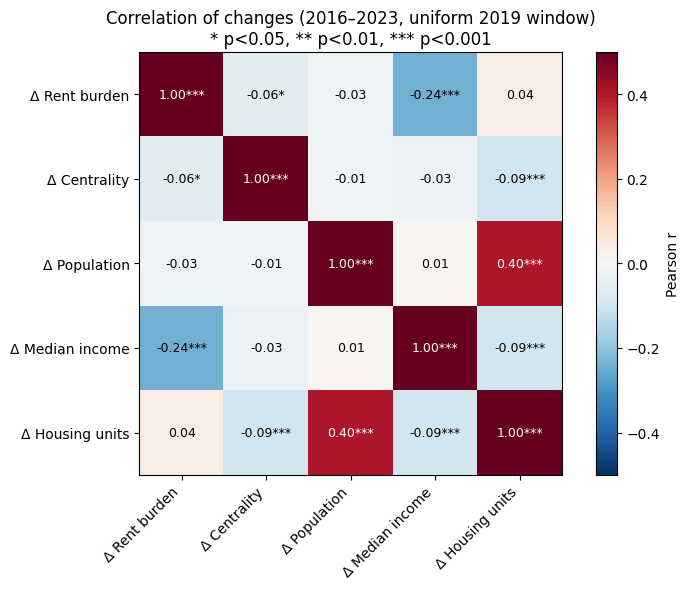

In [443]:
corr_base = did_df.copy()

# Compute year-over-year changes within tract
corr_base["delta_centrality"] = corr_base.groupby("tract_geoid")[CENTRALITY_COL].diff()
corr_base["delta_rent_burden"] = corr_base.groupby("tract_geoid")["rent_burden_share_30p"].diff()
corr_base["delta_population"] = corr_base.groupby("tract_geoid")["B01003_001E"].diff()
corr_base["delta_median_income"] = corr_base.groupby("tract_geoid")["B19013_001E"].diff()
corr_base["delta_housing_units"] = corr_base.groupby("tract_geoid")["B25001_001E"].diff()

# Variables for correlation (changes, not levels)
corr_vars = [
    "delta_rent_burden",
    "delta_centrality",
    "delta_population",
    "delta_median_income",
    "delta_housing_units",
]
corr_df = corr_base[corr_vars].dropna()

# Rename for display
rename_map = {
    "delta_rent_burden": "Δ Rent burden",
    "delta_centrality": "Δ Centrality",
    "delta_population": "Δ Population",
    "delta_median_income": "Δ Median income",
    "delta_housing_units": "Δ Housing units",
}
corr_df = corr_df.rename(columns=rename_map)

# Pearson correlation matrix
corr_matrix = corr_df.corr(method="pearson")

# P-values for each pair (Pearson)
n = corr_df.shape[0]
pval_matrix = pd.DataFrame(
    index=corr_matrix.index, columns=corr_matrix.columns, dtype=float
)
for i, col1 in enumerate(corr_matrix.columns):
    for j, col2 in enumerate(corr_matrix.columns):
        if i <= j:
            r = corr_matrix.loc[col1, col2]
            if abs(r) < 1 and n > 2:
                t_stat = r * np.sqrt(n - 2) / np.sqrt(1 - r**2)
                pval = 2 * (1 - stats.t.cdf(abs(t_stat), n - 2))
            else:
                pval = 0.0
            pval_matrix.loc[col1, col2] = pval
            pval_matrix.loc[col2, col1] = pval

# Print correlation table with significance
print(f"Key correlation: Δ Rent burden vs Δ Centrality ({YEAR_START}–{YEAR_END}, uniform {SHOCK_YEAR} window)")
r_key = corr_matrix.loc["Δ Rent burden", "Δ Centrality"]
p_key = pval_matrix.loc["Δ Rent burden", "Δ Centrality"]
sig = "***" if p_key < 0.001 else "**" if p_key < 0.01 else "*" if p_key < 0.05 else ""
print(f"  r = {r_key:.3f}, p = {p_key:.4f} {sig}")
print()
print("Full correlation matrix (Pearson) with p-values:")
print("-" * 60)
for i, row in enumerate(corr_matrix.index):
    for j, col in enumerate(corr_matrix.columns):
        if i < j:
            r = corr_matrix.loc[row, col]
            p = pval_matrix.loc[row, col]
            sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
            print(f"  {row} vs {col}: r = {r:.3f}, p = {p:.4f} {sig}")
print("\nSignificance: *** p<0.001, ** p<0.01, * p<0.05")

# Pre/Post split: does the centrality-rent correlation change after the shock year?
print(f"\n--- Pre/Post {SHOCK_YEAR} split ---")
for label, mask in [(f"Pre-{SHOCK_YEAR} ({YEAR_START}-{SHOCK_YEAR-1})", corr_base["year"] < SHOCK_YEAR),
                    (f"Post-{SHOCK_YEAR} ({SHOCK_YEAR}-{YEAR_END})", corr_base["year"] >= SHOCK_YEAR)]:
    sub = corr_base[mask][["delta_centrality", "delta_rent_burden"]].dropna()
    if len(sub) > 2:
        r, p = stats.pearsonr(sub["delta_centrality"], sub["delta_rent_burden"])
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        print(f"  {label}: r = {r:.3f}, p = {p:.4f} {sig}  (n={len(sub)})")

# Create heatmap showing correlation of changes in rent burden and centrality
annot_matrix = corr_matrix.copy().astype(object)
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        r = corr_matrix.iloc[i, j]
        p = pval_matrix.iloc[i, j]
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        annot_matrix.iloc[i, j] = f"{r:.2f}{sig}"

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-0.5, vmax=0.5, aspect="equal")
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_matrix.index)
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        color = "white" if abs(corr_matrix.iloc[i, j]) > 0.35 else "black"
        ax.text(j, i, annot_matrix.iloc[i, j], ha="center", va="center", fontsize=9, color=color)
plt.colorbar(im, ax=ax, label="Pearson r")
ax.set_title("Correlation of changes (2016–2023, uniform 2019 window)\n* p<0.05, ** p<0.01, *** p<0.001")
plt.tight_layout()
plt.show()


## Event Study

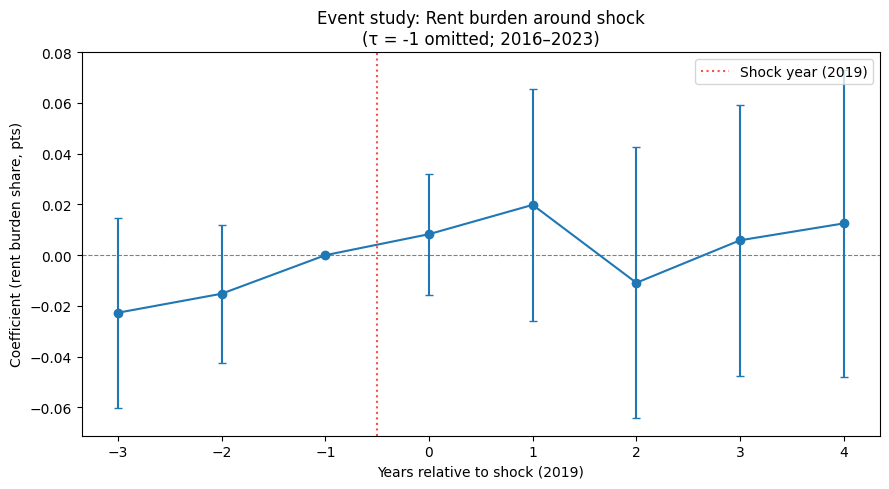


Pre-treatment leads (τ < 0) should be ~0 under parallel trends.
Window: 2016–2023 | Treated: 42 | Control: 146


In [444]:
ev_df = did_df.copy()

# Set relative time to year - shock year
ev_df["rel_time"] = ev_df["year"] - SHOCK_YEAR

# Clip relative time to min/max for plotting
ev_df["rel_time_bin"] = ev_df["rel_time"].clip(REL_MIN, REL_MAX)
ev_df.loc[ev_df["treated"] == 0, "rel_time_bin"] = np.nan

# Create dummy columns for each relative time
dummy_cols = []
tau_to_col = {}
for tau in range(REL_MIN, REL_MAX + 1):
    if tau == -1:
        continue
    col = f"lead_lag_m{abs(tau)}" if tau < 0 else f"lead_lag_{tau}"
    ev_df[col] = ((ev_df["treated"] == 1) & (ev_df["rel_time_bin"] == tau)).astype(float)
    dummy_cols.append(col)
    tau_to_col[tau] = col

for col in ["B01003_001E", "B19013_001E", "B25001_001E"]:
    m, s = ev_df[col].mean(), ev_df[col].std()
    ev_df[f"{col}_std"] = (ev_df[col] - m) / s if s > 0 else 0.0

# Drop missing values and copy for regression
ev_reg = ev_df.dropna(
    subset=["rent_burden_share_30p", "B01003_001E_std", "B19013_001E_std", "B25001_001E_std"]
).copy()
ev_reg[dummy_cols] = ev_reg[dummy_cols].fillna(0)

# Build formula for event study regression
formula = "rent_burden_share_30p ~ " + " + ".join(dummy_cols)
formula += " + B01003_001E_std + B19013_001E_std + B25001_001E_std"
formula += " + C(year) + C(tract_geoid)"

# Fit event study model
event_model = smf.ols(formula, data=ev_reg).fit(
    cov_type="cluster",
    cov_kwds={"groups": ev_reg["tract_geoid"]}
)

# Extract coefficients and confidence intervals
tau_vals = [t for t in range(REL_MIN, REL_MAX + 1) if t != -1]
coefs = [event_model.params.get(tau_to_col[t], 0) for t in tau_vals]
ci_cols = event_model.conf_int().columns.tolist()
ci_lo = [event_model.conf_int().loc[tau_to_col[t], ci_cols[0]] if tau_to_col[t] in event_model.params.index else np.nan for t in tau_vals]
ci_hi = [event_model.conf_int().loc[tau_to_col[t], ci_cols[1]] if tau_to_col[t] in event_model.params.index else np.nan for t in tau_vals]

# Plot event study results
fig, ax = plt.subplots(figsize=(9, 5))
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(-0.5, color="red", linestyle=":", alpha=0.7, label=f"Shock year ({SHOCK_YEAR})")
x_plot = tau_vals.copy()
y_plot = coefs.copy()
err_lo = [c - cl for c, cl in zip(coefs, ci_lo)]
err_hi = [ch - c for c, ch in zip(coefs, ci_hi)]
# Insert omitted reference (τ = -1) at 0 for plotting
idx_insert = sum(1 for t in x_plot if t < -1)
x_plot.insert(idx_insert, -1)
y_plot.insert(idx_insert, 0)
err_lo.insert(idx_insert, 0)
err_hi.insert(idx_insert, 0)

# Plot results
ax.errorbar(x_plot, y_plot, yerr=[err_lo, err_hi], fmt="o-", capsize=3, capthick=1)
ax.set_xlabel(f"Years relative to shock ({SHOCK_YEAR})")
ax.set_ylabel("Coefficient (rent burden share, pts)")
ax.set_title(f"Event study: Rent burden around shock\n(τ = -1 omitted; {YEAR_START}–{YEAR_END})")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

print("\nPre-treatment leads (τ < 0) should be ~0 under parallel trends.")
print(f"Window: {ev_reg['year'].min()}–{ev_reg['year'].max()} | Treated: {ev_reg['treated'].sum() // ev_reg['year'].nunique()} | Control: {(1 - ev_reg['treated']).sum() // ev_reg['year'].nunique()}")

## Lagged Effects

#### Years Since Treatment

Test how the effect of transit access on rent burden evolves over time

In [445]:
lag_df = ev_df.copy()

# Exact event time (same time index logic as event study)
lag_df["rel_time"] = lag_df["year"] - SHOCK_YEAR

# Keep exact post-event years (0..4), matching your event-study post window
lag_df["year0"] = (lag_df["rel_time"] == 0).astype(float)
lag_df["year1"] = (lag_df["rel_time"] == 1).astype(float)
lag_df["year2"] = (lag_df["rel_time"] == 2).astype(float)
lag_df["year3"] = (lag_df["rel_time"] == 3).astype(float)
lag_df["year4"] = (lag_df["rel_time"] == 4).astype(float)

# Interactions: treated cohort x exact event year
lag_df["treated_year0"] = lag_df["treated"] * lag_df["year0"]
lag_df["treated_year1"] = lag_df["treated"] * lag_df["year1"]
lag_df["treated_year2"] = lag_df["treated"] * lag_df["year2"]
lag_df["treated_year3"] = lag_df["treated"] * lag_df["year3"]
lag_df["treated_year4"] = lag_df["treated"] * lag_df["year4"]

# Standardize controls
for col in ["B01003_001E", "B19013_001E", "B25001_001E"]:
    if col not in lag_df.columns:
        continue
    m, s = lag_df[col].mean(), lag_df[col].std()
    lag_df[f"{col}_std"] = (lag_df[col] - m) / s if s > 0 else 0.0

# Regression sample
lag_reg = lag_df.dropna(
    subset=[
        "rent_burden_share_30p",
        "treated_year0", "treated_year1", "treated_year2", "treated_year3", "treated_year4",
        "B01003_001E_std", "B19013_001E_std", "B25001_001E_std"
    ]
).copy()

# Exact-year dynamic spec (coefficients are level effects at each tau, not increments)
formula_lag = (
    "rent_burden_share_30p ~ treated_year0 + treated_year1 + treated_year2 + treated_year3 + treated_year4"
    " + B01003_001E_std + B19013_001E_std + B25001_001E_std"
    " + C(year) + C(tract_geoid)"
)

lag_model = smf.ols(formula_lag, data=lag_reg).fit(
    cov_type="cluster",
    cov_kwds={"groups": lag_reg["tract_geoid"]}
)

print("=== Years-since-treatment (exact years): treated × 1(rel_time = 0,1,2,3,4) ===\n")
print(lag_model.summary().tables[1])
print("\nInterpretation: each treated_yeark is the treated-control gap at event time k, relative to omitted pre-period baseline (consistent with event-study normalization).")

=== Years-since-treatment (exact years): treated × 1(rel_time = 0,1,2,3,4) ===

                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         0.3060      0.031      9.839      0.000       0.245       0.367
C(year)[T.2017]                   0.0024      0.005      0.488      0.625      -0.007       0.012
C(year)[T.2018]                   0.0014      0.008      0.175      0.861      -0.015       0.017
C(year)[T.2019]                   0.0015      0.011      0.140      0.888      -0.019       0.022
C(year)[T.2020]                  -0.0096      0.013     -0.717      0.473      -0.036       0.017
C(year)[T.2021]                   0.0079      0.016      0.502      0.615      -0.023       0.039
C(year)[T.2022]                   0.0277      0.018      1.523      0.128      -0.008       0.063
C(year)[T.2023]                   0.03

/opt/miniconda3/envs/senior_thesis/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 221, but rank is 15
  warnings.warn('covariance of constraints does not have full '


In [446]:
print("=== Adjacent-year growth contrasts (effect changes) ===\n")

adj_hypotheses = {
    "2020 vs 2019 growth (year1 - year0)": "treated_year1 - treated_year0 = 0",
    "2021 vs 2020 growth (year2 - year1)": "treated_year2 - treated_year1 = 0",
    "2022 vs 2021 growth (year3 - year2)": "treated_year3 - treated_year2 = 0",
    "2023 vs 2022 growth (year4 - year3)": "treated_year4 - treated_year3 = 0",
}

for label, hyp in adj_hypotheses.items():
    tt = lag_model.t_test(hyp)
    diff = float(np.squeeze(tt.effect))
    se = float(np.squeeze(tt.sd))
    pval = float(np.squeeze(tt.pvalue))
    print(f"{label}: diff={diff:.4f}, se={se:.4f}, p={pval:.4f}")

=== Adjacent-year growth contrasts (effect changes) ===

2020 vs 2019 growth (year1 - year0): diff=0.0116, se=0.0192, p=0.5459
2021 vs 2020 growth (year2 - year1): diff=-0.0307, se=0.0167, p=0.0658
2022 vs 2021 growth (year3 - year2): diff=0.0167, se=0.0132, p=0.2051
2023 vs 2022 growth (year4 - year3): diff=0.0066, se=0.0128, p=0.6044


#### Joint F-Test & Linear Trend

Joint F-Test: Check whether a set of coefficients are jointly different from 0

Linear Trend: Test whether the effect at one point in time is different from the effect at another

In [447]:
# Collect post-treatment columns
post_tau = [0, 1, 2, 3, 4]
post_cols = [tau_to_col[t] for t in post_tau if tau_to_col.get(t) in event_model.params.index]

# Joint F-test: any lagged effect? (H0: each post-treatment coef = 0)
if post_cols:
    ftest_all = event_model.f_test(", ".join([f"{c} = 0" for c in post_cols]))
    print("=== Formal tests on event study lags (τ = 0,1,2,3,4) ===\n")
    print(f"Joint F-test (all post-treatment coefs = 0): F={np.squeeze(ftest_all.fvalue):.4f}, p={ftest_all.pvalue:.4f}")
    if ftest_all.pvalue < 0.05:
        print("  → Reject H0 ⇒ evidence of some lagged effect.\n")
    else:
        print("  → Fail to reject H0 ⇒ no evidence of lagged effect.\n")
else:
    print("Post-treatment columns not found; check tau_to_col and event_model.")

# Linear trend: do effects increase over time? 
if len(post_cols) >= 2 and tau_to_col.get(4) in event_model.params.index and tau_to_col.get(0) in event_model.params.index:
    c4, c0 = tau_to_col[4], tau_to_col[0]
    trend_test = event_model.f_test(f"{c4} - {c0} = 0")
    print(f"Test (τ=4) - (τ=0) = 0 (effect at 4 yrs vs immediate): F={np.squeeze(trend_test.fvalue):.4f}, p={trend_test.pvalue:.4f}")

=== Formal tests on event study lags (τ = 0,1,2,3,4) ===

Joint F-test (all post-treatment coefs = 0): F=1.0236, p=0.4047
  → Fail to reject H0 ⇒ no evidence of lagged effect.

Test (τ=4) - (τ=0) = 0 (effect at 4 yrs vs immediate): F=0.0240, p=0.8771


#### Dynamic Specification

Add last year's rent burden as a regressor; allow for estimating treatment effect net of persistence

In [448]:
dyn_df = ev_df.copy()

# Create lagged outcome variable
dyn_df["rent_burden_lag1"] = dyn_df.groupby("tract_geoid")["rent_burden_share_30p"].shift(1)

# Standardize only controls
for col in ["B01003_001E", "B19013_001E", "B25001_001E"]:
    if col in dyn_df.columns:
        _m, _s = dyn_df[col].mean(), dyn_df[col].std()
        dyn_df[f"{col}_std"] = (dyn_df[col] - _m) / _s if _s > 0 else 0.0

# Drop missing values and copy for regression
dyn_reg = dyn_df.dropna(
    subset=["rent_burden_share_30p", "rent_burden_lag1", "treated_post",
            "B01003_001E_std", "B19013_001E_std", "B25001_001E_std"]
).copy()

# Build formula for dynamic specification
formula_dyn = (
    "rent_burden_share_30p ~ rent_burden_lag1 + treated_post"
    " + B01003_001E_std + B19013_001E_std + B25001_001E_std"
    " + C(year) + C(tract_geoid)"
)

# Fit dynamic specification model
dyn_model = smf.ols(formula_dyn, data=dyn_reg).fit(
    cov_type="cluster", cov_kwds={"groups": dyn_reg["tract_geoid"]}
)

print("=== Dynamic spec: Rent burden ~ lag(rent_burden) + treated_post + controls + FE ===\n")
print(dyn_model.summary().tables[1])
print("\nNote: Nickell bias possible with short T; treat as robustness check.")

=== Dynamic spec: Rent burden ~ lag(rent_burden) + treated_post + controls + FE ===

                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         0.1266      0.025      5.046      0.000       0.077       0.176
C(year)[T.2018]                  -0.0001      0.006     -0.023      0.981      -0.012       0.012
C(year)[T.2019]                   0.0065      0.007      0.937      0.349      -0.007       0.020
C(year)[T.2020]                  -0.0034      0.010     -0.342      0.733      -0.023       0.016
C(year)[T.2021]                   0.0125      0.009      1.340      0.180      -0.006       0.031
C(year)[T.2022]                   0.0320      0.011      2.864      0.004       0.010       0.054
C(year)[T.2023]                   0.0341      0.013      2.703      0.007       0.009       0.059
C(tract_geoid)[T.18097310105]    

/opt/miniconda3/envs/senior_thesis/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 217, but rank is 11
  warnings.warn('covariance of constraints does not have full '


## Heterogeneity

Interact treatment (treated × post-2018) with baseline characteristics to test whether effects vary by:
- Baseline income
- % Renters
- Baseline rent burden

In [449]:
het_df = did_df.copy()

# Pull in baseline characteristics
_bl = het_df[het_df["year"] == BASELINE_YEAR][
    ["tract_geoid", "B19013_001E", "B25070_001E", "B25001_001E",
     "B25070_007E", "B25070_008E", "B25070_009E", "B25070_010E"]
].copy()

# Build baseline characteristics
_bl = _bl.rename(columns={
    "B19013_001E": "baseline_income",
})
_bl["baseline_pct_renters"] = np.where(
    _bl["B25001_001E"] > 0, _bl["B25070_001E"] / _bl["B25001_001E"], np.nan
)
_bl["baseline_pct_renters"] = _bl["baseline_pct_renters"].clip(0.001, 0.999)
_num = _bl["B25070_007E"] + _bl["B25070_008E"] + _bl["B25070_009E"] + _bl["B25070_010E"]
_bl["baseline_rent_burden"] = np.where(
    _bl["B25070_001E"] > 0, _num / _bl["B25070_001E"], np.nan
)
_bl = _bl[["tract_geoid", "baseline_income", "baseline_pct_renters", "baseline_rent_burden"]]

# Attach baseline to full panel
het_df = het_df.merge(_bl, on="tract_geoid", how="left")

# Standardize controls and baseline characteristics (not treated_post)
for col in ["B01003_001E", "B19013_001E", "B25001_001E",
            "baseline_income", "baseline_pct_renters", "baseline_rent_burden"]:
    if col not in het_df.columns:
        continue
    m, s = het_df[col].mean(), het_df[col].std()
    het_df[f"{col}_std"] = (het_df[col] - m) / s if s > 0 else 0.0

# Drop missing values and copy for regression
het_reg = het_df.dropna(
    subset=["rent_burden_share_30p", "treated_post",
            "B01003_001E_std", "B19013_001E_std", "B25001_001E_std",
            "baseline_income_std", "baseline_pct_renters_std", "baseline_rent_burden_std"]
).copy()

# Build formula for heterogeneity analysis
base_formula = (
    "rent_burden_share_30p ~ treated_post"
    " + B01003_001E_std + B19013_001E_std + B25001_001E_std"
    " + C(year) + C(tract_geoid)"
)

# Set up interaction terms
hetero_results = {}
inter_names = {
    "income": "treated_post:baseline_income_std",
    "pct_renters": "treated_post:baseline_pct_renters_std",
    "rent_burden": "treated_post:baseline_rent_burden_std",
}
for mod_name, inter_var in [
    ("income", "treated_post * baseline_income_std"),
    ("pct_renters", "treated_post * baseline_pct_renters_std"),
    ("rent_burden", "treated_post * baseline_rent_burden_std"),
]:
    # Replace C(tract_geoid) with interaction term
    if mod_name == "pct_renters":
        formula = base_formula.replace("C(tract_geoid)", f"{inter_var} + C(tract_geoid)")
    else:
        formula = base_formula.replace("C(tract_geoid)", f"{inter_var} + C(tract_geoid)")
    
    # Fit model
    m = smf.ols(formula, data=het_reg).fit(
        cov_type="cluster", cov_kwds={"groups": het_reg["tract_geoid"]}
    )
    hetero_results[mod_name] = m
    print(f"\n--- Heterogeneity (uniform 2019): Treatment × {mod_name} ---")
    idx = [i for i in m.params.index if "treated_post" in i or "baseline" in i or i == "Intercept"]
    print(m.params[idx].round(4))
    pv = m.pvalues.get(inter_names[mod_name], np.nan)
    print(f"Interaction p-value: {pv:.4f}")

print("\nInterpretation: significant interaction → effect varies with baseline characteristic.")
print(f"Baseline = {BASELINE_YEAR}")


--- Heterogeneity (uniform 2019): Treatment × income ---
Intercept                           0.3358
treated_post                        0.0153
baseline_income_std                -0.0582
treated_post:baseline_income_std    0.0103
dtype: float64
Interaction p-value: 0.3328

--- Heterogeneity (uniform 2019): Treatment × pct_renters ---
Intercept                                0.3108
treated_post                             0.0215
baseline_pct_renters_std                -0.0072
treated_post:baseline_pct_renters_std    0.0098
dtype: float64
Interaction p-value: 0.4924

--- Heterogeneity (uniform 2019): Treatment × rent_burden ---
Intercept                                0.4394
treated_post                             0.0150
baseline_rent_burden_std                 0.1016
treated_post:baseline_rent_burden_std   -0.0192
dtype: float64
Interaction p-value: 0.2440

Interpretation: significant interaction → effect varies with baseline characteristic.
Baseline = 2018


## Neighborhood Centrality Shock (within distance)

In [ ]:
DIST_MI = 1  # radius for neighborhood (miles)
DIST_M = DIST_MI * 1609.34  # meters

nb_df = did_df.copy()
if "treated_own" not in nb_df.columns:
    nb_df["delta_centrality_raw"] = nb_df.groupby("tract_geoid")[CENTRALITY_COL].diff()
    thresh = nb_df["delta_centrality_raw"].abs().quantile(0.75)
    nb_df["centrality_shock"] = nb_df["delta_centrality_raw"].abs() >= thresh
    nb_df["treated_own"] = nb_df.groupby("tract_geoid")["centrality_shock"].transform("max").astype(int)

# Tract-level "ever-shock" flag (for neighborhood definition)
tract_ever_shock = nb_df.groupby("tract_geoid")["centrality_shock"].max().astype(int)

# Load tracts and project to UTM
tracts = load_tracts(STATE_FIPS)
tracts["tract_geoid"] = tracts["GEOID"].astype(str)
tracts = tracts[tracts["tract_geoid"].isin(nb_df["tract_geoid"].unique())].copy()
utm = "EPSG:26916"
tracts_utm = tracts.to_crs(utm)
tracts_utm["centroid"] = tracts_utm.geometry.representative_point()

# Pairwise distances (meters)
geoms = list(tracts_utm["centroid"].values)
coords = np.array([[g.x, g.y] for g in geoms])
dists = cdist(coords, coords)
tid = tracts_utm["tract_geoid"].values

# For each tract i: treated_neighbor = 1 if any j within D mi had ever_shock
treated_neighbor = {}
for i, ti in enumerate(tid):
    neighbors = tid[dists[i, :] <= DIST_M]
    treated_neighbor[ti] = 1 if tract_ever_shock.reindex(neighbors).fillna(0).max() >= 1 else 0

nb_df["treated"] = nb_df["tract_geoid"].map(treated_neighbor)
nb_df["treated_post"] = nb_df["treated"] * nb_df["post"]

# Standardize only controls
CONTROL_COLS = ["B01003_001E", "B19013_001E", "B25001_001E"]
nb_reg = nb_df.dropna(subset=["rent_burden_share_30p", "treated_post"] + CONTROL_COLS).copy()
for col in CONTROL_COLS:
    m, s = nb_reg[col].mean(), nb_reg[col].std()
    nb_reg[f"{col}_std"] = (nb_reg[col] - m) / s if s > 0 else 0.0

# Run DiD regression
nb_model = smf.ols(
    """rent_burden_share_30p ~ treated_post
       + B01003_001E_std + B19013_001E_std + B25001_001E_std
       + C(year) + C(tract_geoid)""",
    data=nb_reg
).fit(cov_type="cluster", cov_kwds={"groups": nb_reg["tract_geoid"]})

print(f"=== DiD: Rent Burden ~ Neighbor Centrality Shock (within {DIST_MI} mi) ===")
print(f"Treated = any tract within {DIST_MI} mi had centrality shock. Uniform 2018, 2015–2022.\n")
print(nb_model.summary().tables[1])
coef = nb_model.params.get("treated_post", np.nan)
pval = nb_model.pvalues.get("treated_post", np.nan)
print(f"\nNeighbor-shock DiD coef: {coef:.4f}, p = {pval:.4f}")
print(f"Treated tracts (neighbor had shock): {(nb_reg['treated']==1).sum() // nb_reg['year'].nunique()}")
print(f"Control tracts: {(nb_reg['treated']==0).sum() // nb_reg['year'].nunique()}")

=== DiD: Rent Burden ~ Neighbor Centrality Shock (within 1 mi) ===
Treated = any tract within 1 mi had centrality shock. Uniform 2018, 2015–2022.

                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         0.3320      0.030     11.170      0.000       0.274       0.390
C(year)[T.2017]                   0.0026      0.005      0.528      0.598      -0.007       0.012
C(year)[T.2018]                   0.0018      0.008      0.221      0.825      -0.014       0.018
C(year)[T.2019]                  -0.0183      0.015     -1.214      0.225      -0.048       0.011
C(year)[T.2020]                  -0.0268      0.017     -1.549      0.121      -0.061       0.007
C(year)[T.2021]                  -0.0153      0.019     -0.796      0.426      -0.053       0.022
C(year)[T.2022]                   0.0084      0.021      0.404      0

/opt/miniconda3/envs/senior_thesis/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 217, but rank is 11
  warnings.warn('covariance of constraints does not have full '


In [38]:
# --- ALTERNATIVE: Neighborhood shock using 2018→2019 treatment definition (Red Line–aligned) ---
# Replace "ever-shock" with tracts that had large centrality change in 2018→2019 only.

pre_nb = nb_df[nb_df["year"] == BASELINE_YEAR][["tract_geoid", "eigen_or_katz_mean"]].rename(
    columns={"eigen_or_katz_mean": "eigen_pre"}
)
post_nb = nb_df[nb_df["year"] == SHOCK_YEAR][["tract_geoid", "eigen_or_katz_mean"]].rename(
    columns={"eigen_or_katz_mean": "eigen_post"}
)
shock_nb = post_nb.merge(pre_nb, on="tract_geoid", how="inner")
shock_nb["delta_2019"] = shock_nb["eigen_post"] - shock_nb["eigen_pre"]

THRESHOLD_QUANTILE = 0.75
_threshold_nb = shock_nb["delta_2019"].abs().quantile(THRESHOLD_QUANTILE)
treated_tracts_2019 = set(shock_nb[shock_nb["delta_2019"].abs() >= _threshold_nb]["tract_geoid"])

# Tract-level flag: 1 if tract had 2018→2019 shock (for neighborhood definition)
tract_ever_shock_2019 = pd.Series({t: 1 if t in treated_tracts_2019 else 0 for t in tid})

# Recompute treated_neighbor using 2018→2019 definition
treated_neighbor = {}
for i, ti in enumerate(tid):
    neighbors = tid[dists[i, :] <= DIST_M]
    treated_neighbor[ti] = 1 if tract_ever_shock_2019.reindex(neighbors).fillna(0).max() >= 1 else 0

nb_df["treated"] = nb_df["tract_geoid"].map(treated_neighbor)
nb_df["treated_post"] = nb_df["treated"] * nb_df["post"]

# Re-standardize only controls
CONTROL_COLS = ["B01003_001E", "B19013_001E", "B25001_001E"]
nb_reg = nb_df.dropna(subset=["rent_burden_share_30p", "treated_post"] + CONTROL_COLS).copy()
for col in CONTROL_COLS:
    m, s = nb_reg[col].mean(), nb_reg[col].std()
    nb_reg[f"{col}_std"] = (nb_reg[col] - m) / s if s > 0 else 0.0

# Re-run DiD
nb_model = smf.ols(
    """rent_burden_share_30p ~ treated_post
       + B01003_001E_std + B19013_001E_std + B25001_001E_std
       + C(year) + C(tract_geoid)""",
    data=nb_reg
).fit(cov_type="cluster", cov_kwds={"groups": nb_reg["tract_geoid"]})

coef = nb_model.params.get("treated_post", np.nan)
pval = nb_model.pvalues.get("treated_post", np.nan)
print("=== DiD: Neighbor Centrality Shock (2018→2019 Red Line–aligned) ===\n")
print(f"Treated = any tract within {DIST_MI} mi had 2018→2019 centrality shock.\n")
print(nb_model.summary().tables[1])
print(f"\nNeighbor-shock DiD coef: {coef:.4f}, p = {pval:.4f}")
print(f"Treated tracts (neighbor had 2018→2019 shock): {(nb_reg['treated']==1).sum() // nb_reg['year'].nunique()}")
print(f"Control tracts: {(nb_reg['treated']==0).sum() // nb_reg['year'].nunique()}")

=== DiD: Neighbor Centrality Shock (2018→2019 Red Line–aligned) ===

Treated = any tract within 1 mi had 2018→2019 centrality shock.

                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         0.3270      0.029     11.443      0.000       0.271       0.383
C(year)[T.2017]                   0.0025      0.005      0.522      0.601      -0.007       0.012
C(year)[T.2018]                   0.0017      0.008      0.213      0.831      -0.014       0.018
C(year)[T.2019]                  -0.0055      0.012     -0.459      0.646      -0.029       0.018
C(year)[T.2020]                  -0.0140      0.014     -1.005      0.315      -0.041       0.013
C(year)[T.2021]                  -0.0024      0.016     -0.153      0.879      -0.034       0.029
C(year)[T.2022]                   0.0213      0.018      1.209      0.227      -0.

/opt/miniconda3/envs/senior_thesis/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 217, but rank is 11
  warnings.warn('covariance of constraints does not have full '


In [39]:
# Extract main regression stats
summary_stats = {
    "N": int(nb_model.nobs),
    "R_squared": nb_model.rsquared,
    "Adj_R_squared": nb_model.rsquared_adj,
    "F_stat": nb_model.fvalue,
    "F_pvalue": nb_model.f_pvalue,
    "AIC": nb_model.aic,
    "BIC": nb_model.bic
}

summary_df = pd.DataFrame.from_dict(
    summary_stats, orient="index", columns=["Value"]
)

# Extract coefficient of interest
coef_name = "treated_post"

coef_table = pd.DataFrame({
    "Coefficient": [nb_model.params[coef_name]],
    "Std. Error": [nb_model.bse[coef_name]],
    "z-stat": [nb_model.tvalues[coef_name]],
    "P-value": [nb_model.pvalues[coef_name]],
    "CI Lower (95%)": [nb_model.conf_int().loc[coef_name, 0]],
    "CI Upper (95%)": [nb_model.conf_int().loc[coef_name, 1]],
}, index=[coef_name])

print("=== Model Summary ===")
print(summary_df.round(3))

print("\n=== Key Coefficient ===")
print(coef_table.round(3))

coef_val = nb_model.params[coef_name]
ci = nb_model.conf_int().loc[coef_name]
baseline = nb_reg.loc[(nb_reg["treated"] == 0) & (nb_reg["year"] < SHOCK_YEAR), "rent_burden_share_30p"].mean()
print("\n=== Interpretation ===")
print(interpret_coef_percent(coef_val, ci_lo=ci[0], ci_hi=ci[1], baseline=baseline))

=== Model Summary ===
                      Value
N              1.511000e+03
R_squared      6.790000e-01
Adj_R_squared  6.250000e-01
F_stat         8.929185e+11
F_pvalue       0.000000e+00
AIC           -3.095740e+03
BIC           -1.935865e+03

=== Key Coefficient ===
              Coefficient  Std. Error  z-stat  P-value  CI Lower (95%)  \
treated_post         0.03       0.019   1.634    0.102          -0.006   

              CI Upper (95%)  
treated_post           0.067  

=== Interpretation ===
Percentage points: 3.05 pp
As percent: 3.0%
95% CI: [-0.61, 6.71] pp
Relative to baseline (51.0%): 6.0% increase


## Spatial Lag Model (SAR) – Formal Spillover Test

In [40]:
DIST_MI = 1  # radius for neighborhood (miles)
DIST_M = DIST_MI * 1609.34  # meters

sar_df = did_df.copy()

# Average rent burden and treatment status by tract
post_avg = sar_df[sar_df["post"] == 1].groupby("tract_geoid").agg({
    "rent_burden_share_30p": "mean",
    "treated": "max",
    "B01003_001E": "mean",
    "B19013_001E": "mean",
    "B25001_001E": "mean",
}).reset_index()
post_avg = post_avg.rename(columns={
    "B01003_001E": "pop", "B19013_001E": "income", "B25001_001E": "housing"
})

# Load tracts and project to UTM
tracts = load_tracts(STATE_FIPS)
tracts["tract_geoid"] = tracts["GEOID"].astype(str)
utm = "EPSG:26916"
tracts_utm = tracts.to_crs(utm)
tracts_utm["centroid"] = tracts_utm.geometry.representative_point()
tracts_utm = tracts_utm[tracts_utm["tract_geoid"].isin(post_avg["tract_geoid"])].copy()

# Create spatial weights matrix (encode who counts as neighbors)
gdf_cent = tracts_utm[["tract_geoid", "centroid"]].copy()
gdf_cent = gdf_cent.set_geometry("centroid")
gdf_cent = gdf_cent.merge(post_avg, on="tract_geoid", how="inner")
gdf_cent = gdf_cent.dropna(subset=["rent_burden_share_30p", "pop", "income", "housing"])
W = DistanceBand.from_dataframe(gdf_cent, threshold=DIST_M, ids="tract_geoid")
W.transform = "r"

# Align data with the weights
gdf_cent = gdf_cent.set_index("tract_geoid").reindex(W.id_order).dropna().reset_index()

# Prepare data for model
y = gdf_cent["rent_burden_share_30p"].values.reshape(-1, 1)
x = gdf_cent[["treated", "pop", "income", "housing"]].values
x = (x - x.mean(axis=0)) / (x.std(axis=0) + 1e-10)

# Run SAR model
print("=== SAR: Rent burden ~ ρ*W*rent_burden + treated + controls ===")
print("Cross-section: post-treatment (2018-2022) average. W = 0.5 mi distance band.\n")

sar = ML_Lag(y, x, W, name_y="rent_burden", name_x=["treated", "pop", "income", "housing"])
print(f"Rho (spatial lag): {sar.rho:.4f}  (spillover of outcome)")
print(f"Treated coef:      {sar.betas[1, 0]:.4f}")
print(f"Pseudo R²:         {sar.pr2:.4f}")

# Run Spatial Durbin model
print("\n=== Spatial Durbin: adds W*X (spillover of covariates) ===")
sdm = ML_Lag(y, x, W, slx_lags=1, name_y="rent_burden", name_x=["treated", "pop", "income", "housing"])
print(f"Rho:               {sdm.rho:.4f}")
print(f"Treated coef:      {sdm.betas[1, 0]:.4f}")
idx_wt = [i for i, n in enumerate(sdm.name_x) if "W_treated" in str(n)]
if idx_wt:
    print(f"W_treated (spillover): {sdm.betas[idx_wt[0], 0]:.4f}")
print("\nInterpretation: ρ > 0 → rent burden spills over across nearby tracts.")

('WARNING: ', '18097342300', ' is an island (no neighbors)')
('WARNING: ', '18097342400', ' is an island (no neighbors)')
('WARNING: ', '18097342500', ' is an island (no neighbors)')
('WARNING: ', '18097342600', ' is an island (no neighbors)')
('WARNING: ', '18097350100', ' is an island (no neighbors)')
('WARNING: ', '18097380200', ' is an island (no neighbors)')
('WARNING: ', '18097380402', ' is an island (no neighbors)')
('WARNING: ', '18097342000', ' is an island (no neighbors)')
('WARNING: ', '18097310201', ' is an island (no neighbors)')
('WARNING: ', '18097340500', ' is an island (no neighbors)')
('WARNING: ', '18097360202', ' is an island (no neighbors)')
('WARNING: ', '18097310104', ' is an island (no neighbors)')
('WARNING: ', '18097310105', ' is an island (no neighbors)')
('WARNING: ', '18097331000', ' is an island (no neighbors)')
('WARNING: ', '18097390602', ' is an island (no neighbors)')
('WARNING: ', '18097310112', ' is an island (no neighbors)')
('WARNING: ', '180973202

/opt/miniconda3/envs/senior_thesis/lib/python3.13/site-packages/libpysal/weights/util.py:819: UserWarning: The weights matrix is not fully connected: 
 There are 78 disconnected components.
 There are 57 islands with ids: 18097342300, 18097342400, 18097342500, 18097342600, 18097350100, 18097380200, 18097380402, 18097342000, 18097310201, 18097340500, 18097360202, 18097310104, 18097310105, 18097331000, 18097390602, 18097310112, 18097320205, 18097370204, 18097361601, 18097330211, 18097320206, 18097390802, 18097361402, 18097358100, 18097360201, 18097360301, 18097360302, 18097360401, 18097360501, 18097360502, 18097310111, 18097342101, 18097310204, 18097361300, 18097310203, 18097342200, 18097320105, 18097330401, 18097330500, 18097330600, 18097330900, 18097340101, 18097381002, 18097381205, 18097340600, 18097320400, 18097320500, 18097321001, 18097321002, 18097321100, 18097320106, 18097320107, 18097320109, 18097330106, 18097360406, 18097370303, 18097390405.
  w = W(neighbors, weights, ids, **kw

## Weighted Network Graph (Robustness)

In [492]:
# ========== WEIGHTED ANALYSIS PARAMETERS (change these for robustness) ==========
WEIGHT_TYPE = "frequency"           # "time" | "distance" | "frequency"
WEIGHT_AGGREGATE = "mean"      # for time/distance: "mean" | "median" | "min"
WEIGHT_INVERSE_TIME = False    # True => weight = 1/mean_time (shorter time = stronger link)

CENTRALITY_COL_WEIGHTED = "eigen_or_katz_mean"   # same options as unweighted: eigen_or_katz_mean, betweenness_mean, closeness_mean, pagerank_mean, degree_mean
THRESHOLD_QUANTILE_WEIGHTED = 0.75                # same as unweighted: 0.5, 0.75, 0.9 for robustness

In [493]:
def load_gtfs_for_weights(zip_path):
    """Load GTFS and ensure stop_times has time and distance columns for weighted graph."""
    with zipfile.ZipFile(zip_path, "r") as z:
        def read(name):
            return pd.read_csv(z.open(name))
        stops = read("stops.txt")
        routes = read("routes.txt")
        trips = read("trips.txt")
        stop_times = read("stop_times.txt")
    stops["stop_lat"] = stops["stop_lat"].astype(float)
    stops["stop_lon"] = stops["stop_lon"].astype(float)
    stops["stop_id"] = stops["stop_id"].astype(str)
    stop_times["stop_id"] = stop_times["stop_id"].astype(str)
    # shape_dist_traveled may be missing in some feeds; add NaN column if so
    if "shape_dist_traveled" not in stop_times.columns:
        stop_times["shape_dist_traveled"] = np.nan
    return stops, routes, trips, stop_times

def _time_to_minutes(t):
    """Convert GTFS time string (HH:MM:SS or H:MM:SS) to minutes since midnight."""
    if pd.isna(t) or t == "":
        return np.nan
    parts = str(t).strip().split(":")
    if len(parts) < 3:
        return np.nan
    h, m, s = int(parts[0]), int(parts[1]), int(parts[2])
    return h * 60 + m + s / 60.0

def build_bus_graph_weighted(
    gtfs_zip_path,
    weight_type=WEIGHT_TYPE,
    aggregate=WEIGHT_AGGREGATE,
    inverse_time=WEIGHT_INVERSE_TIME
):
    """
    Build bus graph with edge weights. Does not modify the unweighted pipeline.
    - weight_type: "time" (minutes), "distance" (km from shape_dist_traveled), or "frequency" (trip count).
    - aggregate: for time/distance, how to combine across trips ("mean", "median", "min").
    - inverse_time: only for weight_type="time"; use 1/mean_time as weight so shorter = stronger.
    """
    stops, routes, trips, stop_times = load_gtfs_for_weights(gtfs_zip_path)

    bus_routes = routes[routes["route_type"] == 3]
    if len(bus_routes) == 0:
        raise ValueError("GTFS contains no bus routes (route_type = 3).")
    bus_trips = trips[trips["route_id"].isin(bus_routes["route_id"])]
    st = stop_times[stop_times["trip_id"].isin(bus_trips["trip_id"])].copy()

    # Precompute segment values per (trip_id, u, v)
    rows = []
    for trip_id, group in st.groupby("trip_id"):
        group = group.sort_values("stop_sequence").reset_index(drop=True)
        group["arrival_min"] = group["arrival_time"].map(_time_to_minutes)
        group["departure_min"] = group["departure_time"].map(_time_to_minutes)
        for i in range(1, len(group)):
            u = group.iloc[i - 1]["stop_id"]
            v = group.iloc[i]["stop_id"]
            if u == v:
                continue
            dt_min = group.iloc[i]["arrival_min"] - group.iloc[i - 1]["departure_min"]
            if pd.notna(group.iloc[i].get("shape_dist_traveled")) and pd.notna(group.iloc[i - 1].get("shape_dist_traveled")):
                dist_km = (group.iloc[i]["shape_dist_traveled"] - group.iloc[i - 1]["shape_dist_traveled"]) / 1000.0
            else:
                dist_km = np.nan
            rows.append({"trip_id": trip_id, "u": u, "v": v, "time_min": dt_min, "dist_km": dist_km})

    edge_df = pd.DataFrame(rows)

    # Aggregate per (u, v)
    agg = edge_df.groupby(["u", "v"]).agg(
        time_min=("time_min", aggregate),
        dist_km=("dist_km", "mean"),
        trips=("trip_id", "count")
    ).reset_index()

    G = nx.DiGraph()
    for _, r in stops.iterrows():
        G.add_node(
            r["stop_id"],
            name=r["stop_name"],
            lat=r["stop_lat"],
            lon=r["stop_lon"]
        )

    for _, row in agg.iterrows():
        u, v = row["u"], row["v"]
        if weight_type == "time":
            w = row["time_min"]
            if inverse_time and w and w > 0:
                w = 1.0 / w
            elif not np.isfinite(w) or w <= 0:
                w = 1.0
        elif weight_type == "distance":
            w = row["dist_km"] if np.isfinite(row["dist_km"]) and row["dist_km"] > 0 else 1.0
        else:  # frequency
            w = max(1, row["trips"])
        G.add_edge(u, v, weight=w, trips=int(row["trips"]))

    return G

In [494]:
WEIGHTED_GRAPHS_DIR = "data/graphs/Indy_weighted"  # or use a subfolder per weight_type

def build_weighted_graphs_all_years(
    folder_path,
    weight_type=WEIGHT_TYPE,
    aggregate=WEIGHT_AGGREGATE,
    inverse_time=WEIGHT_INVERSE_TIME,
    graphs_base="data/graphs"
):
    """Build weighted graphs for each year and save to a separate directory (does not touch unweighted cache)."""
    import os
    gtfs_paths = build_dict(folder_path)
    if not gtfs_paths:
        raise FileNotFoundError(f"No GTFS zip files found in {folder_path}")

    # e.g. data/graphs/Indy_weighted_time_mean
    suffix = f"{weight_type}_{aggregate}"
    if weight_type == "time" and inverse_time:
        suffix += "_inv"
    abs_folder = os.path.abspath(folder_path.rstrip(os.sep))
    location = os.path.basename(abs_folder)
    graphs_dir = os.path.join(os.path.dirname(abs_folder), "..", graphs_base, f"{location}_weighted_{suffix}")
    os.makedirs(graphs_dir, exist_ok=True)

    graphs = {}
    for year in sorted(gtfs_paths.keys()):
        path = gtfs_paths[year]
        try:
            G = build_bus_graph_weighted(path, weight_type=weight_type, aggregate=aggregate, inverse_time=inverse_time)
            graphs[year] = G
            with open(os.path.join(graphs_dir, f"{year}.gpickle"), "wb") as f:
                pickle.dump(G, f, protocol=pickle.HIGHEST_PROTOCOL)
            print(f"Built weighted graph {year} ({weight_type}, {aggregate}): {len(G.nodes())} nodes, {len(G.edges())} edges.")
        except Exception as e:
            print(f"Error building weighted graph for {year}: {e}")

    return graphs, graphs_dir

In [499]:
def compute_station_centralities_weighted(G, weight_attr="weight"):
    """
    Same as compute_station_centralities but forces use of edge weight.
    When eigenvector/Katz fail to converge (e.g. frequency-weighted graphs),
    falls back to PageRank for the eigen_or_katz column so the run doesn't crash.
    """
    if G.is_directed():
        G = G.to_undirected()
    for u, v, d in list(G.edges(data=True)):
        if weight_attr not in d or not np.isfinite(d.get(weight_attr, 1)):
            G[u][v][weight_attr] = 1.0

    degree_c = nx.degree_centrality(G)
    betweenness_c = nx.betweenness_centrality(G, weight=weight_attr, normalized=True)
    closeness_c = nx.closeness_centrality(G, distance=weight_attr)
    pagerank_c = nx.pagerank(G, weight=weight_attr)

    try:
        eigen_c = eigen_or_katz(G, weight=weight_attr)
    except (nx.PowerIterationFailedConvergence, Exception):
        eigen_c = pagerank_c  # fallback when eigen/Katz don't converge (e.g. frequency weights)

    rows = []
    for node, data in G.nodes(data=True):
        rows.append({
            "station_id": node,
            "station_name": data.get("name"),
            "lat": data.get("lat"),
            "lon": data.get("lon"),
            "degree": degree_c[node],
            "betweenness": betweenness_c[node],
            "closeness": closeness_c[node],
            "eigen_or_katz": eigen_c[node],
            "pagerank": pagerank_c[node]
        })
    return pd.DataFrame(rows).set_index("station_id")

In [500]:
# Example: build time-weighted graphs (run only when you want weighted analysis)
gtfs_folder = "data/raw/Indy"
if not os.path.exists(gtfs_folder):
    gtfs_folder = os.path.join("..", gtfs_folder)

graphs_weighted, weighted_dir = build_weighted_graphs_all_years(
    gtfs_folder,
    weight_type=WEIGHT_TYPE,
    aggregate=WEIGHT_AGGREGATE,
    inverse_time=WEIGHT_INVERSE_TIME
)

# Compute centralities for all years (weighted)
results_weighted = []
for year, G in graphs_weighted.items():
    df = compute_station_centralities_weighted(G, weight_attr="weight")
    df["year"] = year
    df["station_id"] = df.index
    results_weighted.append(df)

centrality_panel_weighted = pd.concat(results_weighted, ignore_index=True)
# From here: merge to tracts (same as you do for unweighted), build tract_panel_weighted,
# then run DiD/correlation using tract_panel_weighted and e.g. eigen_or_katz_mean from the weighted panel.

Built weighted graph 2016 (frequency, mean): 3642 nodes, 3818 edges.
Built weighted graph 2017 (frequency, mean): 3660 nodes, 3871 edges.


/var/folders/pg/8bv44m0n64lc0p4rmm9fm4nh0000gn/T/ipykernel_67989/1945216591.py:5: DtypeWarning: Columns (0: stop_id) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(z.open(name))


Built weighted graph 2018 (frequency, mean): 3626 nodes, 3809 edges.
Built weighted graph 2019 (frequency, mean): 3426 nodes, 3597 edges.
Built weighted graph 2020 (frequency, mean): 2918 nodes, 3083 edges.
Built weighted graph 2021 (frequency, mean): 2899 nodes, 3062 edges.
Built weighted graph 2022 (frequency, mean): 2876 nodes, 3040 edges.
Built weighted graph 2023 (frequency, mean): 2698 nodes, 2841 edges.
Built weighted graph 2024 (frequency, mean): 2468 nodes, 2599 edges.
Built weighted graph 2025 (frequency, mean): 2459 nodes, 2584 edges.
Eigenvector failed for component of size 3641 — switching to Katz.
Katz also failed: (PowerIterationFailedConvergence(...), 'power iteration failed to converge within 1000 iterations')
Eigenvector failed for component of size 3659 — switching to Katz.
Katz also failed: (PowerIterationFailedConvergence(...), 'power iteration failed to converge within 1000 iterations')
Eigenvector failed for component of size 3625 — switching to Katz.
Katz also f

In [501]:
# --- Weighted: assign tracts and aggregate to tract level (same logic as unweighted, separate cache) ---
WEIGHTED_CENTRALITY_CACHE_DIR = Path("data/centralities/Indy_weighted")
WEIGHTED_CENTRALITY_CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Ensure station panel has lat/lon for spatial join (from first year graph if missing)
if "lat" not in centrality_panel_weighted.columns or "lon" not in centrality_panel_weighted.columns:
    first_year = min(graphs_weighted.keys())
    nodes = list(graphs_weighted[first_year].nodes(data=True))
    node_df = pd.DataFrame([
        {"station_id": nid, "lat": d.get("lat"), "lon": d.get("lon")} for nid, d in nodes
    ])
    centrality_panel_weighted = centrality_panel_weighted.merge(
        node_df, on="station_id", how="left"
    )

centrality_with_tracts_weighted = assign_census_tracts(centrality_panel_weighted.copy(), lat_col="lat", lon_col="lon")
centrality_with_tracts_weighted["tract_geoid"] = centrality_with_tracts_weighted["tract_geoid"].astype(str)
centrality_with_tracts_weighted["census_full_code"] = "1400000US" + centrality_with_tracts_weighted["tract_geoid"].astype(str)

# Drop stations that didn't fall in any tract (optional)
centrality_with_tracts_weighted = centrality_with_tracts_weighted.dropna(subset=["tract_geoid"]).copy()
centrality_with_tracts_weighted = centrality_with_tracts_weighted[centrality_with_tracts_weighted["tract_geoid"] != "nan"]

# Aggregate to tract × year (same _sum, _mean, _max as get_tract_centralities)
tract_sum_w = centrality_with_tracts_weighted.groupby(["year", "tract_geoid", "census_full_code"]).agg(
    {"degree": "sum", "betweenness": "sum", "closeness": "sum", "eigen_or_katz": "sum", "pagerank": "sum"}
).reset_index()
tract_mean_w = centrality_with_tracts_weighted.groupby(["year", "tract_geoid", "census_full_code"]).agg(
    {"degree": "mean", "betweenness": "mean", "closeness": "mean", "eigen_or_katz": "mean", "pagerank": "mean"}
).reset_index()
tract_max_w = centrality_with_tracts_weighted.groupby(["year", "tract_geoid", "census_full_code"]).agg(
    {"degree": "max", "betweenness": "max", "closeness": "max", "eigen_or_katz": "max", "pagerank": "max"}
).reset_index()

tract_df_weighted = tract_sum_w.merge(
    tract_mean_w, on=["tract_geoid", "census_full_code", "year"], suffixes=("_sum", "_mean")
).merge(
    tract_max_w, on=["tract_geoid", "census_full_code", "year"], suffixes=("", "_max")
)
tract_df_weighted["tract_geoid"] = tract_df_weighted["tract_geoid"].astype(str)

# Save weighted tract centralities (separate from unweighted)
tract_df_weighted.to_csv(WEIGHTED_CENTRALITY_CACHE_DIR / "tract_centrality_panel_weighted.csv", index=False)
print(f"Saved weighted tract centralities: {tract_df_weighted.shape[0]} rows")

Saved weighted tract centralities: 2095 rows


In [502]:
# --- Build full tract panel for weighted analysis (same ACS data, weighted centralities) ---
rent_panel = load_acs_panel(ACS_OUTCOME_TABLE, acs_base=ACS_BASE)
panels = [load_acs_panel(t, acs_base=ACS_BASE) for t in ACS_CONTROL_TABLES]

def _cols_for_merge(df):
    keep = ["tract_geoid", "year"] + [c for c in df.columns if c.startswith("B") and "_" in c]
    return df[keep]

rent_panel = _cols_for_merge(rent_panel)
panels = [_cols_for_merge(p) for p in panels]
for d in [rent_panel] + panels:
    d["tract_geoid"] = d["tract_geoid"].astype(str)
    d["year"] = d["year"].astype(int)

tract_df_weighted["year"] = tract_df_weighted["year"].astype(int)
final_panel_weighted = tract_df_weighted.merge(rent_panel, on=["tract_geoid", "year"], how="left")
for p in panels:
    final_panel_weighted = final_panel_weighted.merge(p, on=["tract_geoid", "year"], how="left")

# Clean (drop GEO_ID/NAME/unnamed, no raw centrality cols to drop)
drop = [c for c in final_panel_weighted.columns if c.startswith("GEO_ID") or c.startswith("NAME") or (str(c).lower().startswith("unnamed"))]
final_panel_weighted = final_panel_weighted.drop(columns=drop, errors="ignore")

ordered_cols_weighted = [
    "year", "tract_geoid", "census_full_code",
    "degree_sum", "betweenness_sum", "closeness_sum", "eigen_or_katz_sum", "pagerank_sum",
    "degree_mean", "betweenness_mean", "closeness_mean", "eigen_or_katz_mean", "pagerank_mean",
] + [c for c in final_panel_weighted.columns if c not in {
    "year", "tract_geoid", "census_full_code",
    "degree_sum", "betweenness_sum", "closeness_sum", "eigen_or_katz_sum", "pagerank_sum",
    "degree_mean", "betweenness_mean", "closeness_mean", "eigen_or_katz_mean", "pagerank_mean",
}]
final_panel_weighted = final_panel_weighted[[c for c in ordered_cols_weighted if c in final_panel_weighted.columns]]

PANELS_DIR = Path("data/panels/Indy")
TRACT_PANEL_WEIGHTED_FILE = "tract_panel_weighted.csv"
final_panel_weighted.to_csv(PANELS_DIR / TRACT_PANEL_WEIGHTED_FILE, index=False)
print(f"Saved weighted tract panel: {PANELS_DIR / TRACT_PANEL_WEIGHTED_FILE}")

Saved weighted tract panel: data/panels/Indy/tract_panel_weighted.csv


In [503]:
# --- DiD on WEIGHTED panel (does not overwrite did_df / did_model from unweighted) ---
panel_path_weighted = PANELS_DIR / TRACT_PANEL_WEIGHTED_FILE
if not panel_path_weighted.exists():
    panel_path_weighted = Path("..") / panel_path_weighted

did_df_weighted = pd.read_csv(panel_path_weighted)
did_df_weighted["tract_geoid"] = did_df_weighted["tract_geoid"].astype(str)
did_df_weighted["year"] = did_df_weighted["year"].astype(int)
did_df_weighted = did_df_weighted[did_df_weighted["year"].between(YEAR_START, YEAR_END)].copy()

did_df_weighted["post"] = (did_df_weighted["year"] >= SHOCK_YEAR).astype(int)
acs_cols_w = [c for c in did_df_weighted.columns if c.endswith("E")]
did_df_weighted[acs_cols_w] = did_df_weighted[acs_cols_w].apply(pd.to_numeric, errors="coerce")
did_df_weighted["rent_burden_share_30p"] = (
    did_df_weighted["B25070_007E"] + did_df_weighted["B25070_008E"]
    + did_df_weighted["B25070_009E"] + did_df_weighted["B25070_010E"]
) / did_df_weighted["B25070_001E"]
did_df_weighted.loc[did_df_weighted["B25070_001E"] == 0, "rent_burden_share_30p"] = np.nan
did_df_weighted = did_df_weighted.dropna(
    subset=["rent_burden_share_30p", "B01003_001E", "B19013_001E", "B25001_001E"]
)

# Treatment from WEIGHTED centrality (same column name, e.g. eigen_or_katz_mean)
pre_w = did_df_weighted[did_df_weighted["year"] == BASELINE_YEAR][["tract_geoid", CENTRALITY_COL_WEIGHTED]].rename(
    columns={CENTRALITY_COL_WEIGHTED: "centrality_pre"}
)
post_w = did_df_weighted[did_df_weighted["year"] == SHOCK_YEAR][["tract_geoid", CENTRALITY_COL_WEIGHTED]].rename(
    columns={CENTRALITY_COL_WEIGHTED: "centrality_post"}
)
shock_w = post_w.merge(pre_w, on="tract_geoid", how="inner")
shock_w["delta_2019"] = shock_w["centrality_post"] - shock_w["centrality_pre"]
_threshold_w = shock_w["delta_2019"].abs().quantile(THRESHOLD_QUANTILE_WEIGHTED)
treated_tracts_weighted = set(shock_w[shock_w["delta_2019"].abs() >= _threshold_w]["tract_geoid"])

did_df_weighted["treated"] = did_df_weighted["tract_geoid"].isin(treated_tracts_weighted).astype(int)
did_df_weighted["treated_post"] = did_df_weighted["treated"] * did_df_weighted["post"]

for col in ["B01003_001E", "B19013_001E", "B25001_001E"]:
    m, s = did_df_weighted[col].mean(), did_df_weighted[col].std()
    did_df_weighted[f"{col}_std"] = (did_df_weighted[col] - m) / s if s > 0 else 0.0

print("=== DiD: WEIGHTED centrality (2018→2019 treatment) ===")
print(f"  Treated tracts:  {did_df_weighted['treated'].sum() // did_df_weighted['year'].nunique()}")
print(f"  Control tracts: {(1 - did_df_weighted['treated']).sum() // did_df_weighted['year'].nunique()}")
print(f"  Window: {YEAR_START}–{SHOCK_YEAR-1} (pre) | {SHOCK_YEAR}–{YEAR_END} (post)\n")

did_model_weighted = smf.ols(
    """
    rent_burden_share_30p
    ~ treated_post
    + B01003_001E_std + B19013_001E_std + B25001_001E_std
    + C(year)
    + C(tract_geoid)
    """,
    data=did_df_weighted
).fit(cov_type="cluster", cov_kwds={"groups": did_df_weighted["tract_geoid"]})

print(did_model_weighted.summary())

=== DiD: WEIGHTED centrality (2018→2019 treatment) ===
  Treated tracts:  42
  Control tracts: 146
  Window: 2016–2018 (pre) | 2019–2023 (post)

                              OLS Regression Results                             
Dep. Variable:     rent_burden_share_30p   R-squared:                       0.678
Model:                               OLS   Adj. R-squared:                  0.624
Method:                    Least Squares   F-statistic:                     48.44
Date:                   Mon, 16 Mar 2026   Prob (F-statistic):           4.22e-51
Time:                           20:36:08   Log-Likelihood:                 1762.7
No. Observations:                   1511   AIC:                            -3089.
Df Residuals:                       1293   BIC:                            -1929.
Df Model:                            217                                         
Covariance Type:                 cluster                                         
                                   

/opt/miniconda3/envs/senior_thesis/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 217, but rank is 11
  warnings.warn('covariance of constraints does not have full '


In [504]:
# Extract main regression stats
summary_stats = {
    "N": int(did_model_weighted.nobs),
    "R_squared": did_model_weighted.rsquared,
    "Adj_R_squared": did_model_weighted.rsquared_adj,
    "F_stat": did_model_weighted.fvalue,
    "F_pvalue": did_model_weighted.f_pvalue,
    "AIC": did_model_weighted.aic,
    "BIC": did_model_weighted.bic
}

summary_df = pd.DataFrame.from_dict(
    summary_stats, orient="index", columns=["Value"]
)

# Extract coefficient of interest
coef_name = "treated_post"
coef_val = did_model_weighted.params[coef_name]
ci_lo = did_model_weighted.conf_int().loc[coef_name, 0]
ci_hi = did_model_weighted.conf_int().loc[coef_name, 1]

coef_table = pd.DataFrame({
    "Coefficient": [coef_val],
    "Std. Error": [did_model_weighted.bse[coef_name]],
    "z-stat": [did_model_weighted.tvalues[coef_name]],
    "P-value": [did_model_weighted.pvalues[coef_name]],
    "CI Lower (95%)": [ci_lo],
    "CI Upper (95%)": [ci_hi],
}, index=[coef_name])

print("=== Model Summary ===")
print(summary_df.round(3))

print("\n=== Key Coefficient ===")
print(coef_table.round(3))

# Interpretable results (rent_burden_share_30p is 0–1 scale)
baseline = did_df_weighted.loc[
    (did_df_weighted["treated"] == 0) & (did_df_weighted["year"] < SHOCK_YEAR),
    "rent_burden_share_30p"
].mean()
pp = coef_val * 100
pp_lo, pp_hi = ci_lo * 100, ci_hi * 100
pct_rel = (coef_val / baseline * 100) if baseline > 0 else float("nan")

print("\n=== Interpretation ===")
print(f"Percentage points:     {pp:.2f} pp")
print(f"As percent:            {pp:.1f}%")
print(f"95% CI:                [{pp_lo:.2f}, {pp_hi:.2f}] pp")
if baseline > 0:
    print(f"Baseline (control pre): {baseline*100:.1f}%")
    print(f"Relative to baseline:   {pct_rel:.1f}% increase in rent-burdened share")

=== Model Summary ===
                  Value
N              1511.000
R_squared         0.678
Adj_R_squared     0.624
F_stat           48.442
F_pvalue          0.000
AIC           -3089.368
BIC           -1929.493

=== Key Coefficient ===
              Coefficient  Std. Error  z-stat  P-value  CI Lower (95%)  \
treated_post       -0.024       0.023  -1.072    0.284          -0.068   

              CI Upper (95%)  
treated_post            0.02  

=== Interpretation ===
Percentage points:     -2.42 pp
As percent:            -2.4%
95% CI:                [-6.84, 2.00] pp
Baseline (control pre): 49.1%
Relative to baseline:   -4.9% increase in rent-burdened share


In [505]:
# --- Correlation: Δ Rent burden vs Δ Centrality (WEIGHTED panel) ---
corr_base_w = did_df_weighted.copy()
corr_base_w["delta_centrality"] = corr_base_w.groupby("tract_geoid")[CENTRALITY_COL_WEIGHTED].diff()
corr_base_w["delta_rent_burden"] = corr_base_w.groupby("tract_geoid")["rent_burden_share_30p"].diff()
corr_base_w["delta_population"] = corr_base_w.groupby("tract_geoid")["B01003_001E"].diff()
corr_base_w["delta_median_income"] = corr_base_w.groupby("tract_geoid")["B19013_001E"].diff()
corr_base_w["delta_housing_units"] = corr_base_w.groupby("tract_geoid")["B25001_001E"].diff()

corr_vars_w = ["delta_rent_burden", "delta_centrality", "delta_population", "delta_median_income", "delta_housing_units"]
corr_df_w = corr_base_w[corr_vars_w].dropna()
r_centrality_w, p_centrality_w = stats.pearsonr(corr_df_w["delta_rent_burden"], corr_df_w["delta_centrality"])

print(f"Key correlation (WEIGHTED centrality): Δ Rent burden vs Δ Centrality ({YEAR_START}–{YEAR_END})")
print(f"  r = {r_centrality_w:.3f}, p = {p_centrality_w:.4f}")
sig = "***" if p_centrality_w < 0.001 else "**" if p_centrality_w < 0.01 else "*" if p_centrality_w < 0.05 else ""
print(f"  Significance: {sig}\n")

# Pre/Post split
pre_mask = (corr_base_w["year"] > YEAR_START) & (corr_base_w["year"] <= BASELINE_YEAR)
post_mask = corr_base_w["year"] >= SHOCK_YEAR
for label, mask in [("Pre-2019 (2016-2018)", pre_mask), ("Post-2019 (2019-2023)", post_mask)]:
    sub = corr_base_w.loc[mask, ["delta_centrality", "delta_rent_burden"]].dropna()
    if len(sub) < 10:
        print(f"  {label}: n too small")
        continue
    r, p = stats.pearsonr(sub["delta_rent_burden"], sub["delta_centrality"])
    print(f"  {label}: r = {r:.3f}, p = {p:.4f}   (n={len(sub)})")

Key correlation (WEIGHTED centrality): Δ Rent burden vs Δ Centrality (2016–2023)
  r = 0.005, p = 0.8661
  Significance: 

  Pre-2019 (2016-2018): r = nan, p = nan   (n=344)
  Post-2019 (2019-2023): r = 0.005, p = 0.8754   (n=960)


/var/folders/pg/8bv44m0n64lc0p4rmm9fm4nh0000gn/T/ipykernel_67989/91234276.py:26: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = stats.pearsonr(sub["delta_rent_burden"], sub["delta_centrality"])


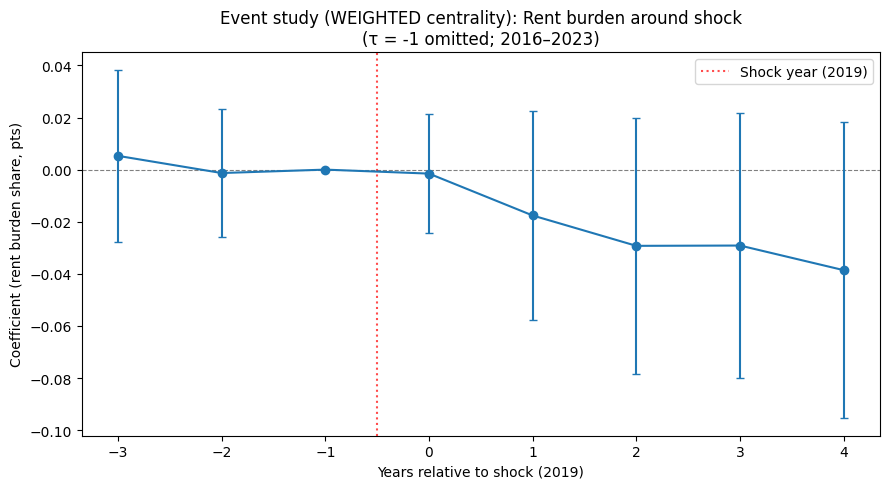

Pre-treatment leads (τ < 0) should be ~0 under parallel trends.
Window: 2016–2023 | Treated: 42 | Control: 146


In [506]:
# --- Event study (WEIGHTED) ---
ev_df_weighted = did_df_weighted.copy()
ev_df_weighted["rel_time"] = ev_df_weighted["year"] - SHOCK_YEAR
ev_df_weighted["rel_time_bin"] = ev_df_weighted["rel_time"].clip(REL_MIN, REL_MAX)
ev_df_weighted.loc[ev_df_weighted["treated"] == 0, "rel_time_bin"] = np.nan

dummy_cols_weighted = []
tau_to_col_weighted = {}
for tau in range(REL_MIN, REL_MAX + 1):
    if tau == -1:
        continue
    col = f"lead_lag_m{abs(tau)}" if tau < 0 else f"lead_lag_{tau}"
    ev_df_weighted[col] = ((ev_df_weighted["treated"] == 1) & (ev_df_weighted["rel_time_bin"] == tau)).astype(float)
    dummy_cols_weighted.append(col)
    tau_to_col_weighted[tau] = col

for col in ["B01003_001E", "B19013_001E", "B25001_001E"]:
    if col in ev_df_weighted.columns:
        m, s = ev_df_weighted[col].mean(), ev_df_weighted[col].std()
        ev_df_weighted[f"{col}_std"] = (ev_df_weighted[col] - m) / s if s > 0 else 0.0

ev_reg_weighted = ev_df_weighted.dropna(
    subset=["rent_burden_share_30p", "B01003_001E_std", "B19013_001E_std", "B25001_001E_std"]
).copy()
ev_reg_weighted[dummy_cols_weighted] = ev_reg_weighted[dummy_cols_weighted].fillna(0)

formula_ev_w = "rent_burden_share_30p ~ " + " + ".join(dummy_cols_weighted)
formula_ev_w += " + B01003_001E_std + B19013_001E_std + B25001_001E_std + C(year) + C(tract_geoid)"
event_model_weighted = smf.ols(formula_ev_w, data=ev_reg_weighted).fit(
    cov_type="cluster", cov_kwds={"groups": ev_reg_weighted["tract_geoid"]}
)

tau_vals_w = [t for t in range(REL_MIN, REL_MAX + 1) if t != -1]
coefs_w = [event_model_weighted.params.get(tau_to_col_weighted[t], 0) for t in tau_vals_w]
ci_cols_w = event_model_weighted.conf_int().columns.tolist()
ci_lo_w = [event_model_weighted.conf_int().loc[tau_to_col_weighted[t], ci_cols_w[0]] if tau_to_col_weighted[t] in event_model_weighted.params.index else np.nan for t in tau_vals_w]
ci_hi_w = [event_model_weighted.conf_int().loc[tau_to_col_weighted[t], ci_cols_w[1]] if tau_to_col_weighted[t] in event_model_weighted.params.index else np.nan for t in tau_vals_w]

fig, ax = plt.subplots(figsize=(9, 5))
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(-0.5, color="red", linestyle=":", alpha=0.7, label=f"Shock year ({SHOCK_YEAR})")
x_plot_w = tau_vals_w.copy()
y_plot_w = coefs_w.copy()
err_lo_w = [c - cl for c, cl in zip(coefs_w, ci_lo_w)]
err_hi_w = [ch - c for c, ch in zip(coefs_w, ci_hi_w)]
idx_insert_w = sum(1 for t in x_plot_w if t < -1)
x_plot_w.insert(idx_insert_w, -1)
y_plot_w.insert(idx_insert_w, 0)
err_lo_w.insert(idx_insert_w, 0)
err_hi_w.insert(idx_insert_w, 0)
ax.errorbar(x_plot_w, y_plot_w, yerr=[err_lo_w, err_hi_w], fmt="o-", capsize=3, capthick=1)
ax.set_xlabel(f"Years relative to shock ({SHOCK_YEAR})")
ax.set_ylabel("Coefficient (rent burden share, pts)")
ax.set_title(f"Event study (WEIGHTED centrality): Rent burden around shock\n(τ = -1 omitted; {YEAR_START}–{YEAR_END})")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()
print("Pre-treatment leads (τ < 0) should be ~0 under parallel trends.")
print(f"Window: {ev_reg_weighted['year'].min()}–{ev_reg_weighted['year'].max()} | Treated: {ev_reg_weighted['treated'].sum() // ev_reg_weighted['year'].nunique()} | Control: {(1 - ev_reg_weighted['treated']).sum() // ev_reg_weighted['year'].nunique()}")

In [488]:
# --- Lagged effects (WEIGHTED): treated_year0 ... treated_year4 ---
lag_df_weighted = ev_df_weighted.copy()
lag_df_weighted["rel_time"] = lag_df_weighted["year"] - SHOCK_YEAR
lag_df_weighted["year0"] = (lag_df_weighted["rel_time"] == 0).astype(float)
lag_df_weighted["year1"] = (lag_df_weighted["rel_time"] == 1).astype(float)
lag_df_weighted["year2"] = (lag_df_weighted["rel_time"] == 2).astype(float)
lag_df_weighted["year3"] = (lag_df_weighted["rel_time"] == 3).astype(float)
lag_df_weighted["year4"] = (lag_df_weighted["rel_time"] == 4).astype(float)
lag_df_weighted["treated_year0"] = lag_df_weighted["treated"] * lag_df_weighted["year0"]
lag_df_weighted["treated_year1"] = lag_df_weighted["treated"] * lag_df_weighted["year1"]
lag_df_weighted["treated_year2"] = lag_df_weighted["treated"] * lag_df_weighted["year2"]
lag_df_weighted["treated_year3"] = lag_df_weighted["treated"] * lag_df_weighted["year3"]
lag_df_weighted["treated_year4"] = lag_df_weighted["treated"] * lag_df_weighted["year4"]

for col in ["B01003_001E", "B19013_001E", "B25001_001E"]:
    if col in lag_df_weighted.columns:
        m, s = lag_df_weighted[col].mean(), lag_df_weighted[col].std()
        lag_df_weighted[f"{col}_std"] = (lag_df_weighted[col] - m) / s if s > 0 else 0.0

lag_reg_weighted = lag_df_weighted.dropna(
    subset=[
        "rent_burden_share_30p",
        "treated_year0", "treated_year1", "treated_year2", "treated_year3", "treated_year4",
        "B01003_001E_std", "B19013_001E_std", "B25001_001E_std"
    ]
).copy()

formula_lag_w = (
    "rent_burden_share_30p ~ treated_year0 + treated_year1 + treated_year2 + treated_year3 + treated_year4"
    " + B01003_001E_std + B19013_001E_std + B25001_001E_std"
    " + C(year) + C(tract_geoid)"
)
lag_model_weighted = smf.ols(formula_lag_w, data=lag_reg_weighted).fit(
    cov_type="cluster", cov_kwds={"groups": lag_reg_weighted["tract_geoid"]}
)
print("=== Lagged effects (WEIGHTED): treated × 1(rel_time = 0,1,2,3,4) ===\n")
print(lag_model_weighted.summary().tables[1])
print("\nInterpretation: each treated_yeark is the treated-control gap at event time k (τ = -1 omitted).")

=== Lagged effects (WEIGHTED): treated × 1(rel_time = 0,1,2,3,4) ===

                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         0.3230      0.030     10.745      0.000       0.264       0.382
C(year)[T.2017]                   0.0025      0.005      0.509      0.611      -0.007       0.012
C(year)[T.2018]                   0.0016      0.008      0.201      0.841      -0.014       0.017
C(year)[T.2019]                   0.0019      0.010      0.187      0.852      -0.018       0.022
C(year)[T.2020]                  -0.0136      0.014     -1.003      0.316      -0.040       0.013
C(year)[T.2021]                  -0.0030      0.016     -0.192      0.848      -0.034       0.028
C(year)[T.2022]                   0.0157      0.018      0.896      0.370      -0.019       0.050
C(year)[T.2023]                   0.0288      0.

/opt/miniconda3/envs/senior_thesis/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 221, but rank is 15
  warnings.warn('covariance of constraints does not have full '


In [489]:
# --- Joint F-test and (τ=4)-(τ=0) (WEIGHTED) ---
post_tau_w = [0, 1, 2, 3, 4]
post_cols_w = [tau_to_col_weighted[t] for t in post_tau_w if tau_to_col_weighted.get(t) in event_model_weighted.params.index]
if post_cols_w:
    ftest_w = event_model_weighted.f_test(", ".join([f"{c} = 0" for c in post_cols_w]))
    print("=== Formal tests (WEIGHTED): event study lags τ = 0,1,2,3,4 ===\n")
    print(f"Joint F-test (all post-treatment coefs = 0): F={np.squeeze(ftest_w.fvalue):.4f}, p={ftest_w.pvalue:.4f}")
    print("  → Reject H0 ⇒ evidence of lagged effect." if ftest_w.pvalue < 0.05 else "  → Fail to reject H0 ⇒ no evidence of lagged effect.")
if tau_to_col_weighted.get(4) in event_model_weighted.params.index and tau_to_col_weighted.get(0) in event_model_weighted.params.index:
    c4, c0 = tau_to_col_weighted[4], tau_to_col_weighted[0]
    trend_w = event_model_weighted.f_test(f"{c4} - {c0} = 0")
    print(f"\nTest (τ=4) - (τ=0) = 0: F={np.squeeze(trend_w.fvalue):.4f}, p={trend_w.pvalue:.4f}")

=== Formal tests (WEIGHTED): event study lags τ = 0,1,2,3,4 ===

Joint F-test (all post-treatment coefs = 0): F=2.5214, p=0.0306
  → Reject H0 ⇒ evidence of lagged effect.

Test (τ=4) - (τ=0) = 0: F=2.0579, p=0.1529


In [490]:
# --- Dynamic specification (WEIGHTED) ---
dyn_df_weighted = ev_df_weighted.copy()
dyn_df_weighted["rent_burden_lag1"] = dyn_df_weighted.groupby("tract_geoid")["rent_burden_share_30p"].shift(1)
for col in ["B01003_001E", "B19013_001E", "B25001_001E"]:
    if col in dyn_df_weighted.columns:
        _m, _s = dyn_df_weighted[col].mean(), dyn_df_weighted[col].std()
        dyn_df_weighted[f"{col}_std"] = (dyn_df_weighted[col] - _m) / _s if _s > 0 else 0.0
dyn_reg_weighted = dyn_df_weighted.dropna(
    subset=["rent_burden_share_30p", "rent_burden_lag1", "treated_post",
            "B01003_001E_std", "B19013_001E_std", "B25001_001E_std"]
).copy()
formula_dyn_w = (
    "rent_burden_share_30p ~ rent_burden_lag1 + treated_post"
    " + B01003_001E_std + B19013_001E_std + B25001_001E_std"
    " + C(year) + C(tract_geoid)"
)
dyn_model_weighted = smf.ols(formula_dyn_w, data=dyn_reg_weighted).fit(
    cov_type="cluster", cov_kwds={"groups": dyn_reg_weighted["tract_geoid"]}
)
print("=== Dynamic spec (WEIGHTED): Rent burden ~ lag(rent_burden) + treated_post + controls + FE ===\n")
print(dyn_model_weighted.summary().tables[1])
print("\nNote: Nickell bias possible with short T; treat as robustness check.")

=== Dynamic spec (WEIGHTED): Rent burden ~ lag(rent_burden) + treated_post + controls + FE ===

                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         0.1368      0.025      5.370      0.000       0.087       0.187
C(year)[T.2018]               -9.181e-05      0.006     -0.015      0.988      -0.012       0.012
C(year)[T.2019]               -7.519e-05      0.007     -0.011      0.991      -0.014       0.014
C(year)[T.2020]                  -0.0100      0.010     -0.949      0.343      -0.031       0.011
C(year)[T.2021]                   0.0060      0.010      0.622      0.534      -0.013       0.025
C(year)[T.2022]                   0.0257      0.011      2.263      0.024       0.003       0.048
C(year)[T.2023]                   0.0280      0.013      2.167      0.030       0.003       0.053
C(tract_geoid)[T.18097

/opt/miniconda3/envs/senior_thesis/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 217, but rank is 11
  warnings.warn('covariance of constraints does not have full '


In [491]:
# --- Heterogeneity (WEIGHTED) ---
het_df_weighted = did_df_weighted.copy()
_bl_w = het_df_weighted[het_df_weighted["year"] == BASELINE_YEAR][
    ["tract_geoid", "B19013_001E", "B25070_001E", "B25001_001E",
     "B25070_007E", "B25070_008E", "B25070_009E", "B25070_010E"]
].copy()
_bl_w = _bl_w.rename(columns={"B19013_001E": "baseline_income"})
_bl_w["baseline_pct_renters"] = np.where(
    _bl_w["B25001_001E"] > 0, _bl_w["B25070_001E"] / _bl_w["B25001_001E"], np.nan
)
_bl_w["baseline_pct_renters"] = _bl_w["baseline_pct_renters"].clip(0.001, 0.999)
_num_w = _bl_w["B25070_007E"] + _bl_w["B25070_008E"] + _bl_w["B25070_009E"] + _bl_w["B25070_010E"]
_bl_w["baseline_rent_burden"] = np.where(
    _bl_w["B25070_001E"] > 0, _num_w / _bl_w["B25070_001E"], np.nan
)
_bl_w = _bl_w[["tract_geoid", "baseline_income", "baseline_pct_renters", "baseline_rent_burden"]]
het_df_weighted = het_df_weighted.merge(_bl_w, on="tract_geoid", how="left")

for col in ["B01003_001E", "B19013_001E", "B25001_001E", "baseline_income", "baseline_pct_renters", "baseline_rent_burden"]:
    if col in het_df_weighted.columns:
        m, s = het_df_weighted[col].mean(), het_df_weighted[col].std()
        het_df_weighted[f"{col}_std"] = (het_df_weighted[col] - m) / s if s > 0 else 0.0

het_reg_weighted = het_df_weighted.dropna(
    subset=["rent_burden_share_30p", "treated_post",
            "B01003_001E_std", "B19013_001E_std", "B25001_001E_std",
            "baseline_income_std", "baseline_pct_renters_std", "baseline_rent_burden_std"]
).copy()

base_formula_w = (
    "rent_burden_share_30p ~ treated_post"
    " + B01003_001E_std + B19013_001E_std + B25001_001E_std"
    " + C(year) + C(tract_geoid)"
)
inter_names_w = {
    "income": "treated_post:baseline_income_std",
    "pct_renters": "treated_post:baseline_pct_renters_std",
    "rent_burden": "treated_post:baseline_rent_burden_std",
}
for mod_name, inter_term in [
    ("income", "treated_post * baseline_income_std"),
    ("pct_renters", "treated_post * baseline_pct_renters_std"),
    ("rent_burden", "treated_post * baseline_rent_burden_std"),
]:
    formula_w = base_formula_w.replace("C(tract_geoid)", f"{inter_term} + C(tract_geoid)")
    m_w = smf.ols(formula_w, data=het_reg_weighted).fit(
        cov_type="cluster", cov_kwds={"groups": het_reg_weighted["tract_geoid"]}
    )
    print(f"\n--- Heterogeneity (WEIGHTED): Treatment × {mod_name} ---")
    idx_w = [i for i in m_w.params.index if "treated_post" in i or "baseline" in i or i == "Intercept"]
    print(m_w.params[idx_w].round(4))
    print(f"Interaction p-value: {m_w.pvalues.get(inter_names_w[mod_name], np.nan):.4f}")
print("\nInterpretation: significant interaction → effect varies with baseline characteristic.")
print(f"Baseline = {BASELINE_YEAR}")


--- Heterogeneity (WEIGHTED): Treatment × income ---
Intercept                           0.3497
treated_post                        0.0488
baseline_income_std                -0.0495
treated_post:baseline_income_std    0.0019
dtype: float64
Interaction p-value: 0.9194

--- Heterogeneity (WEIGHTED): Treatment × pct_renters ---
Intercept                                0.3270
treated_post                             0.0489
baseline_pct_renters_std                -0.0060
treated_post:baseline_pct_renters_std   -0.0095
dtype: float64
Interaction p-value: 0.5210

--- Heterogeneity (WEIGHTED): Treatment × rent_burden ---
Intercept                                0.4489
treated_post                             0.0479
baseline_rent_burden_std                 0.0869
treated_post:baseline_rent_burden_std   -0.0090
dtype: float64
Interaction p-value: 0.5597

Interpretation: significant interaction → effect varies with baseline characteristic.
Baseline = 2018


## Archive